In [2]:
import re
import string

# Esta función limpia el texto eliminando números, signos y convirtiendo a minúsculas
def limpiar_texto(texto):
    texto = str(texto).lower()  # convierto todo a minúsculas
    texto = re.sub(r"\d+", "", texto)  # elimino números
    texto = texto.translate(str.maketrans("", "", string.punctuation))  # elimino signos
    texto = texto.strip()  # elimino espacios al inicio y final
    return texto

# Aquí hago un preprocesamiento más completo del texto
def preprocesar_texto(texto):
    texto = limpiar_texto(texto)
    palabras = texto.split()  # separo el texto en palabras
    return " ".join(palabras)  # vuelvo a unir limpio

# Esta función tokeniza el texto (lo convierte en lista de palabras)
def tokenizar(texto):
    texto = preprocesar_texto(texto)
    return texto.split()

In [3]:
# Aquí pruebo cómo funciona el preprocesamiento con un ejemplo real

texto_ejemplo = "Hola!!! Quiero comprar una laptop 2025!!!"

print("Texto original:", texto_ejemplo)

# Aplico la limpieza del texto
print("Texto limpio:", preprocesar_texto(texto_ejemplo))

# Tokenizo el texto (lo convierto en palabras individuales)
print("Tokens:", tokenizar(texto_ejemplo))

Texto original: Hola!!! Quiero comprar una laptop 2025!!!
Texto limpio: hola quiero comprar una laptop
Tokens: ['hola', 'quiero', 'comprar', 'una', 'laptop']


In [4]:
from pathlib import Path
import pandas as pd

#  
# 📁 CONFIGURACIÓN DE RUTAS
#  

# Ruta base (donde está el notebook)
BASE_DIR = Path.cwd()

# Intento primero: notebooks/data
DATA_DIR = BASE_DIR / "data"

# Si no existe, intento: ../data (cuando data está fuera de notebooks)
if not DATA_DIR.exists():
    DATA_DIR = BASE_DIR.parent / "data"

print("📁 Usando carpeta data en:", DATA_DIR)


#  
# 📥 CARGAR CONVERSACIONES
#  

def cargar_conversaciones():
    ruta = DATA_DIR / "conversaciones_500.csv"

    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")

    df = pd.read_csv(ruta)

    # Renombro columnas
    df.columns = ["input", "output"]

    # Aseguro tipo texto
    df["input"] = df["input"].astype(str)
    df["output"] = df["output"].astype(str)

    return df


#  
# 📥 CARGAR PRODUCTOS
#  

def cargar_productos():
    ruta = DATA_DIR / "amazon_1000_products.csv"

    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")

    df = pd.read_csv(ruta)

    # Normalizo columnas
    df.columns = [c.lower().strip() for c in df.columns]

    # Limpieza de datos
    df["category"] = df["category"].astype(str).str.lower().str.strip()
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

    # Elimino filas inválidas
    df = df.dropna(subset=["name", "brand", "category", "price", "rating", "review"])

    return df


#  
# 🧪 PRUEBA DE CARGA
#  

df_conversaciones = cargar_conversaciones()
df_productos = cargar_productos()

print("\n📊 Dataset de conversaciones:")
display(df_conversaciones.head())

print("\n📦 Dataset de productos:")
display(df_productos.head())

print("\n📈 Cantidad de conversaciones:", len(df_conversaciones))
print("📈 Cantidad de productos:", len(df_productos))

📁 Usando carpeta data en: c:\Users\walin\Downloads\IA-chatbot\server\data

📊 Dataset de conversaciones:


,input,output
0,hola,Hola 😊 ¿Qué producto estás buscando?
1,hello,Hola 😊 ¿Qué producto estás buscando?
2,hi,Hola 😊 ¿Qué producto estás buscando?
3,buenas,Hola 😊 ¿Qué producto estás buscando?
4,cual es buena laptop,Una buena laptop depende de tu presupuesto y uso



📦 Dataset de productos:


,name,brand,category,price,rating,review,dorecommend
0,Acer S20,Acer,phone,486,4.8,Highly recommended product,1
1,Motorola S18,Motorola,phone,1032,5.0,Battery lasts long and smooth usage,1
2,Xiaomi Tab A10,Xiaomi,tablet,695,4.1,Very good for the price,1
3,Asus Tab S6,Asus,tablet,206,4.4,Battery lasts long and smooth usage,1
4,HP GT15,HP,phone,309,3.7,Excellent quality and design,0



📈 Cantidad de conversaciones: 504
📈 Cantidad de productos: 1000


In [5]:
# Cargo ambos datasets para verificar que todo esté bien
df_conversaciones = cargar_conversaciones()
df_productos = cargar_productos()

print("Primeras filas del dataset de conversaciones:")
display(df_conversaciones.head())

print("Primeras filas del dataset de productos:")
display(df_productos.head())

print("Cantidad de conversaciones:", len(df_conversaciones))
print("Cantidad de productos:", len(df_productos))

Primeras filas del dataset de conversaciones:


,input,output
0,hola,Hola 😊 ¿Qué producto estás buscando?
1,hello,Hola 😊 ¿Qué producto estás buscando?
2,hi,Hola 😊 ¿Qué producto estás buscando?
3,buenas,Hola 😊 ¿Qué producto estás buscando?
4,cual es buena laptop,Una buena laptop depende de tu presupuesto y uso


Primeras filas del dataset de productos:


,name,brand,category,price,rating,review,dorecommend
0,Acer S20,Acer,phone,486,4.8,Highly recommended product,1
1,Motorola S18,Motorola,phone,1032,5.0,Battery lasts long and smooth usage,1
2,Xiaomi Tab A10,Xiaomi,tablet,695,4.1,Very good for the price,1
3,Asus Tab S6,Asus,tablet,206,4.4,Battery lasts long and smooth usage,1
4,HP GT15,HP,phone,309,3.7,Excellent quality and design,0


Cantidad de conversaciones: 504
Cantidad de productos: 1000


In [6]:
from pathlib import Path
import pandas as pd

# Defino las rutas principales del proyecto
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"

# Esta función carga el dataset de conversaciones del chatbot
def cargar_conversaciones():
    ruta = DATA_DIR / "conversaciones_500.csv"
    df = pd.read_csv(ruta)

    # Renombro las columnas para trabajar más cómodo
    df.columns = ["input", "output"]

    # Aseguro que ambas columnas sean texto
    df["input"] = df["input"].astype(str)
    df["output"] = df["output"].astype(str)

    return df

# Esta función carga el dataset de productos

def cargar_productos():
    base_dir = Path.cwd()

    posibles_rutas = [
        base_dir / "data" / "amazon_1000_products.csv",
        base_dir.parent / "data" / "amazon_1000_products.csv",
        base_dir.parent.parent / "data" / "amazon_1000_products.csv",
        base_dir / "amazon_1000_products.csv",
        base_dir.parent / "amazon_1000_products.csv",
    ]

    ruta = None

    for r in posibles_rutas:
        print("🔍 Probando ruta de productos:", r)
        if r.exists():
            ruta = r
            break

    if ruta is None:
        raise FileNotFoundError("❌ No se encontró amazon_1000_products.csv en ninguna ruta esperada")

    print("✅ Productos encontrados en:", ruta)

    df = pd.read_csv(ruta)

    # Normalizar nombres de columnas
    df.columns = [c.lower().strip() for c in df.columns]

    return df

In [7]:
# 
# IMPORTACIÓN
#  

# Importamos Path para trabajar con rutas del sistema
from pathlib import Path


#  
# VERIFICACIÓN DE RUTAS
#  

# Muestra el directorio actual desde donde se está ejecutando el script
print("Path.cwd():", Path.cwd())

# Verifica si existe una carpeta llamada "data" en el directorio actual
print("Existe ./data?:", (Path.cwd() / "data").exists())

# Verifica si existe una carpeta "data" en el directorio padre
print("Existe ../data?:", (Path.cwd().parent / "data").exists())

Path.cwd(): c:\Users\walin\Downloads\IA-chatbot\server\src
Existe ./data?: False
Existe ../data?: True


In [8]:
#  
# IMPORTS
#  

# Manejo de rutas del sistema
from pathlib import Path

# Manejo de datos
import pandas as pd

# Guardar modelos entrenados
import pickle

# Herramientas de Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


#  
# LIMPIEZA DE TEXTO
#  

# Librería para expresiones regulares
import re

def limpiar_texto(texto):
    """
    Limpia el texto de entrada para mejorar el procesamiento del modelo.
    - Convierte a minúsculas
    - Elimina caracteres especiales
    - Maneja valores nulos
    """
    
    # Si el texto es nulo, retorna vacío
    if pd.isna(texto):
        return ""
    
    # Convertir a minúsculas
    texto = texto.lower()
    
    # Eliminar caracteres que no sean letras (incluye acentos)
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)
    
    return texto


#  
# DETECCIÓN DE INTENCIÓN
#  

def detectar_intencion(texto):
    """
    Clasifica el texto en una intención basada en palabras clave.
    Este método funciona como un etiquetador inicial del dataset.
    """
    
    texto = limpiar_texto(texto)

    # Saludos
    if any(p in texto for p in ["hola", "hello", "hi", "buenas"]):
        return "saludo"
    
    # Laptop
    if any(p in texto for p in ["laptop", "notebook"]):
        return "laptop"
    
    # Tablet
    if "tablet" in texto:
        return "tablet"
    
    # Celular
    if any(p in texto for p in ["celular", "telefono", "teléfono", "phone", "movil", "móvil"]):
        return "celular"
    
    # Precio
    if any(p in texto for p in ["precio", "cuanto cuesta", "cuánto cuesta", "costo", "vale"]):
        return "precio"
    
    # Recomendación
    if any(p in texto for p in ["recomiendame", "recomiéndame", "recomendar"]):
        return "recomendacion"

    # Caso general
    return "general"


#  
# CARGAR DATASET (ROBUSTO)
#  

def cargar_conversaciones():
    """
    Busca el archivo conversaciones_500.csv en varias rutas posibles.
    Esto evita errores de ruta en diferentes entornos.
    """
    
    posibles_rutas = [
        Path.cwd() / "data" / "conversaciones_500.csv",
        Path.cwd().parent / "data" / "conversaciones_500.csv",
        Path.cwd().parent.parent / "data" / "conversaciones_500.csv",
        Path("conversaciones_500.csv")
    ]

    # Intentar encontrar el archivo en distintas ubicaciones
    for ruta in posibles_rutas:
        print("🔍 Probando:", ruta)
        if ruta.exists():
            print("✅ Archivo encontrado en:", ruta)
            df = pd.read_csv(ruta)
            
            # Asegurar nombres de columnas correctos
            df.columns = ["input", "output"]
            return df

    # Si no se encuentra el archivo
    raise FileNotFoundError("❌ No se encontró conversaciones_500.csv en ninguna ruta")


#  
# ENTRENAMIENTO DEL MODELO
#  

print("🔵 Iniciando entrenamiento del modelo...")

# Cargar dataset
df = cargar_conversaciones()

print("📊 Dataset cargado:", df.shape)

# Limpieza de texto
df["input"] = df["input"].astype(str).apply(limpiar_texto)

# Generar etiquetas de intención
df["intent"] = df["input"].apply(detectar_intencion)

# Mostrar distribución de clases
print("\n📊 Distribución de intenciones:")
print(df["intent"].value_counts())


#  
# VARIABLES DE ENTRENAMIENTO
#  

# Entrada (texto)
X = df["input"]

# Salida (intención)
y = df["intent"]


#  
# VECTORIZACIÓN (TF-IDF)
#  

"""
Convierte texto a números para que el modelo pueda entenderlo.
Usa:
- unigramas (1 palabra)
- bigramas (2 palabras)
"""
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=3000
)

# Transformar texto a vectores numéricos
X_vec = vectorizer.fit_transform(X)


#  
# MODELO (LOGISTIC REGRESSION)
#  

"""
Modelo de clasificación supervisada que aprende a predecir la intención.
"""
model = LogisticRegression(max_iter=1000)

# Entrenar modelo
model.fit(X_vec, y)

print("\n✅ Modelo entrenado correctamente")
print("Clases aprendidas:", list(model.classes_))


#  
# GUARDAR MODELO
#  

"""
Se guardan el modelo y el vectorizador para reutilizarlos
sin tener que entrenar nuevamente.
"""

with open("modelo_intenciones.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("💾 Modelo y vectorizer guardados")


#  
# FUNCIÓN DE PREDICCIÓN
#  

def predecir(texto):
    """
    Recibe un texto y devuelve la intención predicha.
    """
    
    texto_limpio = limpiar_texto(texto)
    texto_vec = vectorizer.transform([texto_limpio])
    pred = model.predict(texto_vec)[0]
    
    return pred


#  
# PRUEBAS DEL MODELO
#  

print("\n🧪 PRUEBAS:")

print("Hola ->", predecir("hola"))
print("Quiero una laptop ->", predecir("quiero una laptop"))
print("Cuanto cuesta ->", predecir("cuanto cuesta"))

🔵 Iniciando entrenamiento del modelo...
🔍 Probando: c:\Users\walin\Downloads\IA-chatbot\server\src\data\conversaciones_500.csv
🔍 Probando: c:\Users\walin\Downloads\IA-chatbot\server\data\conversaciones_500.csv
✅ Archivo encontrado en: c:\Users\walin\Downloads\IA-chatbot\server\data\conversaciones_500.csv
📊 Dataset cargado: (504, 2)

📊 Distribución de intenciones:
intent
laptop     138
tablet     134
celular    128
general    100
saludo       4
Name: count, dtype: int64

✅ Modelo entrenado correctamente
Clases aprendidas: ['celular', 'general', 'laptop', 'saludo', 'tablet']
💾 Modelo y vectorizer guardados

🧪 PRUEBAS:
Hola -> general
Quiero una laptop -> laptop
Cuanto cuesta -> general


In [9]:
#  
# FUNCIÓN DE PREDICCIÓN DE INTENCIÓN
#  

def predecir_intencion(texto):
    """
    Recibe un texto del usuario y devuelve la intención predicha
    utilizando el modelo previamente entrenado.
    """
    
    # Paso 1: Limpiar el texto (minúsculas, sin símbolos, etc.)
    texto_limpio = limpiar_texto(texto)
    
    # Paso 2: Convertir el texto en vector numérico (TF-IDF)
    vector = vectorizer.transform([texto_limpio])
    
    # Paso 3: Predecir la intención usando el modelo
    pred = model.predict(vector)[0]
    
    # Retornar la intención detectada
    return pred


#  
# PRUEBAS DEL MODELO
#  

"""
Se realizan pruebas con diferentes tipos de mensajes
para validar que el modelo reconoce correctamente
las intenciones del usuario.
"""

print(predecir_intencion("hola"))                     # Esperado: saludo
print(predecir_intencion("quiero una laptop"))        # Esperado: laptop
print(predecir_intencion("precio de celular"))        # Esperado: precio o celular
print(predecir_intencion("recomiendame una tablet"))  # Esperado: recomendacion o tablet

general
laptop
celular
tablet


In [10]:
#  
# IMPORTS
#  

# Manejo de datos
import pandas as pd

# Vectorización de texto
from sklearn.feature_extraction.text import TfidfVectorizer

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# División de datos
from sklearn.model_selection import train_test_split

# Métricas de evaluación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Para ROC-AUC multiclase
from sklearn.preprocessing import label_binarize


#  
# DETECCIÓN DE INTENCIÓN
#  

def detectar_intencion(texto):
    """
    Clasifica el texto en una intención basada en palabras clave.
    Esta función se usa para etiquetar automáticamente el dataset.
    """
    
    texto = limpiar_texto(texto)

    if any(p in texto for p in ["hola", "hello", "hi", "buenas"]):
        return "saludo"
    if "laptop" in texto or "notebook" in texto:
        return "laptop"
    if "tablet" in texto:
        return "tablet"
    if any(p in texto for p in ["celular", "telefono", "teléfono", "phone", "movil", "móvil"]):
        return "celular"
    if any(p in texto for p in ["precio", "cuanto cuesta", "cuánto cuesta", "costo", "vale"]):
        return "precio"
    if any(p in texto for p in ["recomiendame", "recomiéndame", "recomendar"]):
        return "recomendacion"

    return "general"


#  
# CARGA Y PREPARACIÓN
#  

print("🔵 Iniciando entrenamiento supervisado...")

# Cargar dataset
df = cargar_conversaciones().copy()

# Limpieza de texto
df["input"] = df["input"].astype(str).apply(limpiar_texto)

# Generar etiquetas (intenciones)
df["intent"] = df["input"].apply(detectar_intencion)

# Información del dataset
print("📊 Dataset cargado:", df.shape)

print("\n📊 Distribución de intenciones:")
print(df["intent"].value_counts())


#  
# VARIABLES
#  

X = df["input"]   # Texto
y = df["intent"]  # Etiquetas


#  
# VECTORIZACIÓN TF-IDF
#  

"""
Convierte el texto en números para que el modelo pueda procesarlo.
Incluye unigramas y bigramas.
"""
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=3000
)

X_vec = vectorizer.fit_transform(X)


#  
# DIVISIÓN TRAIN / TEST
#  

X_train, X_test, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantiene balance de clases
)

print("\n✅ División realizada:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)


#  
# MODELO 1: LOGISTIC REGRESSION
#  

modelo_lr = LogisticRegression(max_iter=1000)

# Entrenar modelo
modelo_lr.fit(X_train, y_train)

# Predicciones
pred_lr = modelo_lr.predict(X_test)


#  
# MODELO 2: RANDOM FOREST
#  

modelo_rf = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

# Entrenar modelo
modelo_rf.fit(X_train, y_train)

# Predicciones
pred_rf = modelo_rf.predict(X_test)


#  
# FUNCIÓN DE EVALUACIÓN
#  

def evaluar_modelo(nombre, y_real, y_pred, modelo=None, X_test=None):
    """
    Calcula métricas de evaluación para un modelo.
    Incluye:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - ROC-AUC (si aplica)
    """
    
    acc = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_real, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_real, y_pred, average="weighted", zero_division=0)

    print(f"\n📌 {nombre}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    # Calcular ROC-AUC si el modelo lo permite
    if modelo is not None and X_test is not None and hasattr(modelo, "predict_proba"):
        
        clases = sorted(y_real.unique())
        y_test_bin = label_binarize(y_real, classes=clases)
        y_prob = modelo.predict_proba(X_test)

        try:
            roc_auc = roc_auc_score(
                y_test_bin,
                y_prob,
                multi_class="ovr",
                average="weighted"
            )
            print(f"ROC-AUC:   {roc_auc:.4f}")
            return acc, precision, recall, f1, roc_auc
        except Exception:
            print("ROC-AUC:   No se pudo calcular")
            return acc, precision, recall, f1, None

    print("ROC-AUC:   No aplica")
    return acc, precision, recall, f1, None


#  
# EVALUACIÓN DE MODELOS
#  

resultados_lr = evaluar_modelo(
    "Logistic Regression",
    y_test,
    pred_lr,
    modelo=modelo_lr,
    X_test=X_test
)

resultados_rf = evaluar_modelo(
    "Random Forest",
    y_test,
    pred_rf,
    modelo=modelo_rf,
    X_test=X_test
)


#  
# TABLA COMPARATIVA
#  

"""
Se crea una tabla para comparar ambos modelos
de forma clara.
"""
comparacion = pd.DataFrame([
    {
        "Modelo": "Logistic Regression",
        "Accuracy": resultados_lr[0],
        "Precision": resultados_lr[1],
        "Recall": resultados_lr[2],
        "F1-score": resultados_lr[3],
        "ROC-AUC": resultados_lr[4],
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": resultados_rf[0],
        "Precision": resultados_rf[1],
        "Recall": resultados_rf[2],
        "F1-score": resultados_rf[3],
        "ROC-AUC": resultados_rf[4],
    }
])

print("\n📊 Comparación final de modelos:")
print(comparacion)

🔵 Iniciando entrenamiento supervisado...
🔍 Probando: c:\Users\walin\Downloads\IA-chatbot\server\src\data\conversaciones_500.csv
🔍 Probando: c:\Users\walin\Downloads\IA-chatbot\server\data\conversaciones_500.csv
✅ Archivo encontrado en: c:\Users\walin\Downloads\IA-chatbot\server\data\conversaciones_500.csv
📊 Dataset cargado: (504, 3)

📊 Distribución de intenciones:
intent
laptop     138
tablet     134
celular    128
general    100
saludo       4
Name: count, dtype: int64

✅ División realizada:
Train: (403, 56)
Test: (101, 56)

📌 Logistic Regression
Accuracy:  0.9901
Precision: 0.9807
Recall:    0.9901
F1-score:  0.9853
ROC-AUC:   1.0000

📌 Random Forest
Accuracy:  0.9901
Precision: 0.9807
Recall:    0.9901
F1-score:  0.9853
ROC-AUC:   1.0000

📊 Comparación final de modelos:
                Modelo  Accuracy  Precision    Recall  F1-score  ROC-AUC
0  Logistic Regression  0.990099   0.980669  0.990099  0.985269      1.0
1        Random Forest  0.990099   0.980669  0.990099  0.985269      1

In [11]:
#  
# IMPORTS (por si faltan)
#  

# Vectorización de texto
from sklearn.feature_extraction.text import TfidfVectorizer

# Algoritmo de clustering
from sklearn.cluster import KMeans

# Métrica para evaluar clusters
from sklearn.metrics import silhouette_score


#  
# ASEGURAR QUE EXISTE df_unsup
#  

"""
Se verifica si existe el DataFrame para aprendizaje no supervisado.
Si no existe, se crea una copia del dataset principal.
"""
if "df_unsup" not in globals():
    df_unsup = df.copy()


#  
# ASEGURAR COLUMNA LIMPIA
#  

"""
Se asegura que exista una columna de texto limpio.
Si no existe, se crea a partir de la columna 'input'.
"""
if "review_clean" not in df_unsup.columns:
    df_unsup["review_clean"] = df_unsup["input"].astype(str).apply(limpiar_texto)


#  
# VECTORIZACIÓN TF-IDF
#  

"""
Convierte el texto en vectores numéricos para aplicar clustering.
"""
vectorizer_unsup = TfidfVectorizer(max_features=3000)

# Transformar texto a matriz numérica
X_unsup = vectorizer_unsup.fit_transform(df_unsup["review_clean"])


#  
# KMEANS + SILHOUETTE
#  

"""
Se prueba KMeans con diferentes valores de K (número de clusters)
y se evalúa con la métrica silhouette_score.
"""
scores = []

for k in range(2, 6):
    # Crear modelo KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Entrenar y obtener etiquetas
    labels = km.fit_predict(X_unsup)
    
    # Calcular silhouette score
    score = silhouette_score(X_unsup, labels)
    
    # Guardar resultados
    scores.append((k, score))
    
    print(f"K={k} -> silhouette={score:.4f}")


#  
# MEJOR K
#  

"""
Se selecciona el número de clusters con mejor desempeño
según el silhouette score.
"""
best_k = max(scores, key=lambda x: x[1])[0]

print(f"\n✅ Mejor número de clusters para KMeans: {best_k}")

K=2 -> silhouette=0.1853
K=3 -> silhouette=0.2664
K=4 -> silhouette=0.3452
K=5 -> silhouette=0.4256

✅ Mejor número de clusters para KMeans: 5


📊 Datos listos para clustering: (504, 7)
✅ Matriz TF-IDF creada: (504, 30)
K=2 -> silhouette=0.1853
K=3 -> silhouette=0.2664
K=4 -> silhouette=0.3452
K=5 -> silhouette=0.4256

✅ Mejor número de clusters para KMeans: 5

Distribución KMeans:
kmeans
1    187
3     83
0     82
2     80
4     72
Name: count, dtype: int64

Distribución DBSCAN:
dbscan
 1     83
 3     83
 2     82
 4     80
 0     72
 7     16
 6     14
 5     13
 11    13
 13    12
 10    11
 12     9
 8      6
 9      6
-1      4
Name: count, dtype: int64

Distribución Agglomerative:
agglomerative
0    187
1     83
2     82
4     80
3     72
Name: count, dtype: int64

Ejemplos por cluster KMeans:

--- Cluster 0 ---
      name      category             review
Sin nombre Sin categoría que es una celular
Sin nombre Sin categoría  que es una laptop
Sin nombre Sin categoría que es una celular
Sin nombre Sin categoría que es una celular
Sin nombre Sin categoría  que es una tablet

--- Cluster 1 ---
      name      category       

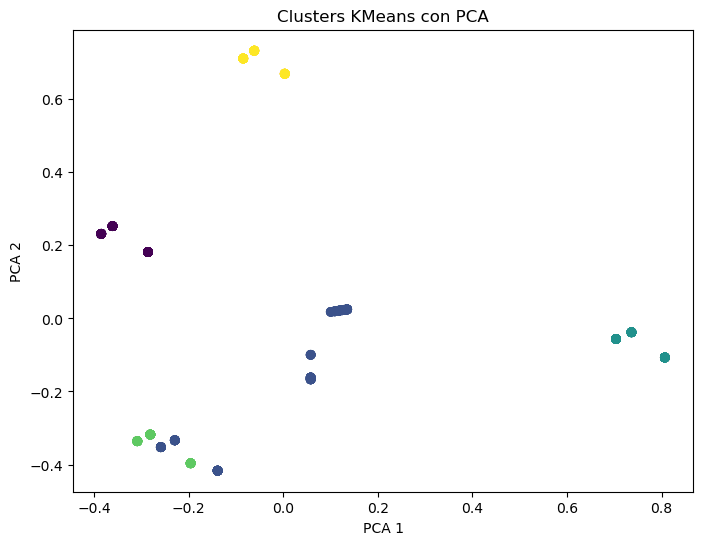

In [12]:
#  
# IMPORTS
#  

# Expresiones regulares (limpieza de texto)
import re

# Manejo de datos
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Manejo de rutas
from pathlib import Path

# Procesamiento de texto
from sklearn.feature_extraction.text import TfidfVectorizer

# Algoritmos de clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Evaluación de clusters
from sklearn.metrics import silhouette_score

# Reducción de dimensionalidad
from sklearn.decomposition import PCA


#  
# FUNCIÓN DE LIMPIEZA
#  

def limpiar_texto(texto):
    """
    Limpia el texto:
    - Convierte a minúsculas
    - Elimina caracteres especiales
    - Normaliza espacios
    """
    
    if pd.isna(texto):
        return ""
    
    texto = str(texto).lower()
    
    # Solo letras, números y espacios
    texto = re.sub(r'[^a-záéíóúñü0-9\s]', '', texto)
    
    # Quitar espacios extras
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto


#  
# CARGAR DATASET
#  

def cargar_conversaciones():
    """
    Busca el dataset en múltiples rutas posibles.
    Evita errores de archivo no encontrado.
    """
    
    posibles_rutas = [
        Path.cwd() / "data" / "conversaciones_500.csv",
        Path.cwd().parent / "data" / "conversaciones_500.csv",
        Path.cwd().parent.parent / "data" / "conversaciones_500.csv",
        Path("conversaciones_500.csv")
    ]

    for ruta in posibles_rutas:
        print("🔍 Probando:", ruta)
        if ruta.exists():
            print("✅ Archivo encontrado en:", ruta)
            
            df_local = pd.read_csv(ruta)
            
            # Asegurar estructura correcta
            if len(df_local.columns) >= 2:
                df_local = df_local.iloc[:, :2]
                df_local.columns = ["input", "output"]
            
            return df_local

    raise FileNotFoundError("❌ No se encontró conversaciones_500.csv en ninguna ruta")


# Si no existe df, se carga automáticamente
if "df" not in globals():
    df = cargar_conversaciones()


#  
# PREPARAR DATASET
#  

df_unsup = df.copy()

# Si no existe 'review', usar 'input'
if "review" not in df_unsup.columns:
    df_unsup["review"] = df_unsup["input"].astype(str)

# Crear columnas si no existen (evita errores)
if "name" not in df_unsup.columns:
    df_unsup["name"] = "Sin nombre"

if "category" not in df_unsup.columns:
    df_unsup["category"] = "Sin categoría"

# Limpiar texto
df_unsup["review_clean"] = df_unsup["review"].astype(str).apply(limpiar_texto)

# Eliminar textos vacíos
df_unsup = df_unsup[df_unsup["review_clean"].str.strip() != ""].copy()

print("📊 Datos listos para clustering:", df_unsup.shape)


#  
# VECTORIZACIÓN TF-IDF
#  

"""
Convierte el texto en vectores numéricos.
"""
vectorizer_unsup = TfidfVectorizer(max_features=3000)
X_unsup = vectorizer_unsup.fit_transform(df_unsup["review_clean"])

print("✅ Matriz TF-IDF creada:", X_unsup.shape)


#  
# BUSCAR MEJOR K (KMEANS)
#  

scores = []

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = km.fit_predict(X_unsup)
    
    score = silhouette_score(X_unsup, labels)
    scores.append((k, score))
    
    print(f"K={k} -> silhouette={score:.4f}")

# Seleccionar mejor K
best_k = max(scores, key=lambda x: x[1])[0]

print(f"\n✅ Mejor número de clusters para KMeans: {best_k}")


#  
# APLICAR MODELOS
#  

# KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_unsup["kmeans"] = kmeans.fit_predict(X_unsup)

# DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=3)
df_unsup["dbscan"] = dbscan.fit_predict(X_unsup.toarray())

# Clustering jerárquico
agglomerative = AgglomerativeClustering(n_clusters=best_k)
df_unsup["agglomerative"] = agglomerative.fit_predict(X_unsup.toarray())


#  
# DISTRIBUCIÓN DE CLUSTERS
#  

print("\nDistribución KMeans:")
print(df_unsup["kmeans"].value_counts())

print("\nDistribución DBSCAN:")
print(df_unsup["dbscan"].value_counts())

print("\nDistribución Agglomerative:")
print(df_unsup["agglomerative"].value_counts())


#  
# EJEMPLOS POR CLUSTER
#  

print("\nEjemplos por cluster KMeans:")

for cluster_id in sorted(df_unsup["kmeans"].unique()):
    print(f"\n--- Cluster {cluster_id} ---")
    
    muestras = df_unsup[df_unsup["kmeans"] == cluster_id][["name", "category", "review"]].head(5)
    
    print(muestras.to_string(index=False))


#  
# VISUALIZACIÓN CON PCA
#  

"""
Reduce dimensiones para poder graficar los clusters.
"""
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsup.toarray())

plt.figure(figsize=(8, 6))

# Gráfico de clusters
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_unsup["kmeans"])

plt.title("Clusters KMeans con PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [13]:
#  
# IMPORTS
#  

# Permite cargar objetos guardados (modelos entrenados)
import pickle

# Manejo de rutas del sistema
from pathlib import Path


#  
# CONFIGURACIÓN DE RUTAS
#  

# Directorio actual donde se ejecuta el script
BASE_DIR = Path.cwd()

# Carpeta donde se espera encontrar los modelos
MODELS_DIR = BASE_DIR / "models"

# Si no existe en la carpeta actual, buscar en el directorio padre
if not MODELS_DIR.exists():
    MODELS_DIR = BASE_DIR.parent / "models"

# Mostrar ruta donde se buscarán los modelos
print("📁 Buscando modelos en:", MODELS_DIR)


#  
# CLASE MODELO DE INTENCIÓN
#  

class ModeloIntencion:
    """
    Clase encargada de:
    - Cargar el modelo entrenado
    - Cargar el vectorizador TF-IDF
    - Predecir la intención de un texto
    """

    def __init__(self):
        # Rutas de los archivos del modelo
        model_path = MODELS_DIR / "model.pkl"
        vectorizer_path = MODELS_DIR / "vectorizer.pkl"

        # Validar que el modelo existe
        if not model_path.exists():
            raise FileNotFoundError(f"No se encontró el modelo en: {model_path}")

        # Validar que el vectorizador existe
        if not vectorizer_path.exists():
            raise FileNotFoundError(f"No se encontró el vectorizer en: {vectorizer_path}")

        # Cargar modelo entrenado
        with open(model_path, "rb") as f:
            self.model = pickle.load(f)

        # Cargar vectorizador TF-IDF
        with open(vectorizer_path, "rb") as f:
            self.vectorizer = pickle.load(f)

    def predecir(self, texto):
        """
        Recibe un texto y devuelve la intención predicha.
        """
        
        # Convertir texto a vector numérico
        X = self.vectorizer.transform([texto])
        
        # Predecir intención
        return self.model.predict(X)[0]


#  
# INSTANCIAR MODELO
#  

# Se crea una instancia del modelo para usarlo
modelo = ModeloIntencion()


#  
# PRUEBAS
#  

"""
Se prueban diferentes textos para verificar que el modelo
funciona correctamente.
"""

print(modelo.predecir("hola"))                     # Esperado: saludo
print(modelo.predecir("quiero una laptop"))        # Esperado: laptop
print(modelo.predecir("precio de celular"))        # Esperado: precio o celular
print(modelo.predecir("recomiendame una tablet"))  # Esperado: recomendacion

📁 Buscando modelos en: c:\Users\walin\Downloads\IA-chatbot\server\models
general
laptop
celular
tablet


⚠️ El paquete 'wordcloud' no está instalado. Esa parte se omitirá.
🔍 Probando: c:\Users\walin\Downloads\IA-chatbot\server\src\data\amazon_1000_products.csv
🔍 Probando: c:\Users\walin\Downloads\IA-chatbot\server\data\amazon_1000_products.csv
✅ Dataset encontrado en: c:\Users\walin\Downloads\IA-chatbot\server\data\amazon_1000_products.csv

📊 Columnas encontradas en el dataset:
['name', 'brand', 'category', 'price', 'rating', 'review', 'doRecommend']

✅ Dataset limpio: (1000, 9)

📌 Top 15 palabras más frecuentes:
[('and', 402), ('for', 215), ('but', 207), ('battery', 204), ('product', 160), ('very', 128), ('good', 128), ('the', 128), ('price', 128), ('excellent', 112), ('quality', 112), ('design', 112), ('not', 109), ('bad', 109), ('has', 109)]

📌 Top 10 bigramas:
[('good price', np.int64(128)), ('excellent quality', np.int64(112)), ('quality design', np.int64(112)), ('bad issues', np.int64(109)), ('battery lasts', np.int64(105)), ('lasts long', np.int64(105)), ('long smooth', np.int64(10

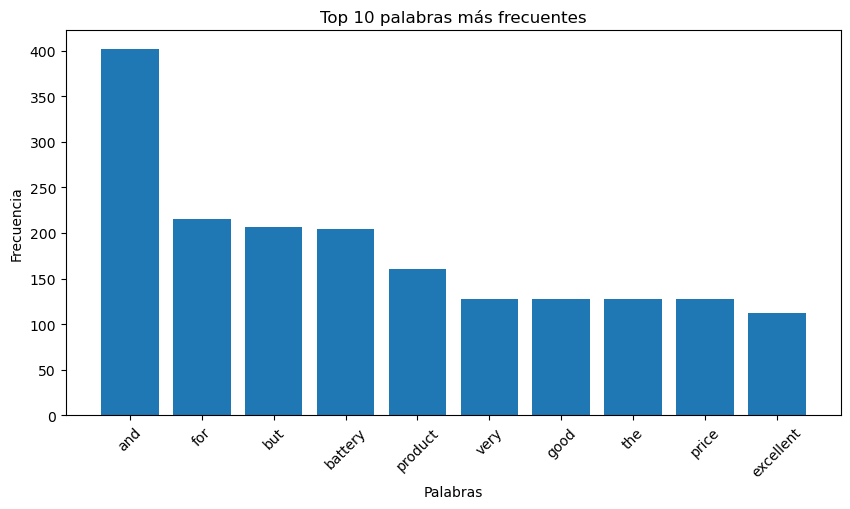


⚠️ WordCloud no disponible


In [14]:
#  
# IMPORTS
#  

# Librería para trabajar con expresiones regulares (limpieza de texto)
import re

# Librería para manejo de datos (DataFrames)
import pandas as pd

# Librería para graficar resultados
import matplotlib.pyplot as plt

# Librería para manejar rutas del sistema (evita errores de ubicación)
from pathlib import Path

# Contador de palabras (frecuencia)
from collections import Counter

# Vectorizador para análisis de texto (bag of words)
from sklearn.feature_extraction.text import CountVectorizer

# Modelo de tópicos (LDA - Latent Dirichlet Allocation)
from sklearn.decomposition import LatentDirichletAllocation


#  
# WORDCLOUD (OPCIONAL)
#  

"""
Intentamos importar WordCloud.
Si no está instalado, simplemente omitimos esa parte del código
sin que el programa falle.
"""
try:
    from wordcloud import WordCloud
    WORDCLOUD_DISPONIBLE = True
except ModuleNotFoundError:
    WORDCLOUD_DISPONIBLE = False
    print("⚠️ El paquete 'wordcloud' no está instalado. Esa parte se omitirá.")


#  
# FUNCIONES BÁSICAS
#  

def preprocesar_texto(texto):
    """
    Esta función limpia el texto para análisis NLP.

    PASOS:
    1. Convierte todo a minúsculas
    2. Elimina caracteres especiales
    3. Normaliza espacios
    """

    # Si el texto está vacío o es nulo, retornar vacío
    if pd.isna(texto):
        return ""
    
    # Convertir a string y minúsculas
    texto = str(texto).lower()

    # Eliminar todo lo que no sea letras, números o espacios
    texto = re.sub(r'[^a-záéíóúñü0-9\s]', ' ', texto)

    # Eliminar espacios repetidos
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto


def tokenizar(texto):
    """
    Convierte el texto en una lista de palabras (tokens).
    """

    # Si está vacío, devolver lista vacía
    if pd.isna(texto):
        return []

    # Primero limpiar texto, luego dividirlo
    return preprocesar_texto(texto).split()


#  
# FUNCIONES NLP AVANZADAS
#  

def obtener_bigramas(textos, top_n=10):
    """
    Extrae los pares de palabras más frecuentes (bigramas).
    
    Ejemplo:
    "muy bueno" o "excelente producto"
    """

    # Crear vectorizador de bigramas (2 palabras juntas)
    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words="english")

    # Convertir textos a matriz numérica
    X = vectorizer.fit_transform(textos)

    # Sumar frecuencia de cada bigrama
    frecuencias = X.sum(axis=0).A1

    # Obtener palabras asociadas
    vocabulario = vectorizer.get_feature_names_out()

    # Ordenar de mayor a menor frecuencia
    pares = sorted(zip(vocabulario, frecuencias), key=lambda x: x[1], reverse=True)

    # Retornar los top N
    return pares[:top_n]


def mostrar_temas_lda(textos, n_topics=3, n_palabras=6):
    """
    Detecta temas dentro del texto usando LDA.

    LDA agrupa palabras que suelen aparecer juntas
    para formar temas.
    """

    # Convertir texto a matriz de frecuencia
    vectorizer = CountVectorizer(stop_words="english")
    X = vectorizer.fit_transform(textos)

    # Crear modelo LDA
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)

    # Entrenar modelo
    lda.fit(X)

    # Obtener palabras
    palabras = vectorizer.get_feature_names_out()

    print("\n🧠 Temas detectados con LDA:")

    # Mostrar temas
    for i, tema in enumerate(lda.components_):
        top = tema.argsort()[-n_palabras:][::-1]
        palabras_tema = [palabras[j] for j in top]

        print(f"Tema {i + 1}: {palabras_tema}")


#  
# BUSCAR DATASET
#  

"""
Se intenta encontrar automáticamente el dataset
en diferentes ubicaciones del sistema.
Esto evita errores comunes de rutas.
"""

BASE_DIR = Path.cwd()

posibles_rutas = [
    BASE_DIR / "data" / "amazon_1000_products.csv",
    BASE_DIR.parent / "data" / "amazon_1000_products.csv",
    BASE_DIR.parent.parent / "data" / "amazon_1000_products.csv",
    BASE_DIR / "amazon_1000_products.csv",
    BASE_DIR.parent / "amazon_1000_products.csv",
]

ruta_productos = None

# Buscar archivo
for ruta in posibles_rutas:
    print("🔍 Probando:", ruta)
    if ruta.exists():
        ruta_productos = ruta
        print("✅ Dataset encontrado en:", ruta_productos)
        break

# Si no se encuentra, error crítico
if ruta_productos is None:
    raise FileNotFoundError("❌ No se encontró amazon_1000_products.csv en ninguna ruta esperada")


#  
# CARGAR DATASET
#  

df_nlp = pd.read_csv(ruta_productos)

print("\n📊 Columnas encontradas en el dataset:")
print(df_nlp.columns.tolist())


#  
# VALIDAR COLUMNAS
#  

"""
Se verifica que existan las columnas necesarias
para el análisis.
"""

columnas_requeridas = ["review", "rating"]

for col in columnas_requeridas:
    if col not in df_nlp.columns:
        raise ValueError(f"❌ Falta la columna requerida: {col}")

# Crear columnas si faltan (para evitar errores)
if "name" not in df_nlp.columns:
    df_nlp["name"] = "Sin nombre"

if "category" not in df_nlp.columns:
    df_nlp["category"] = "Sin categoría"


#  
# LIMPIEZA DEL DATASET
#  

# Eliminar filas con valores nulos
df_nlp = df_nlp.dropna(subset=["review", "rating"]).copy()

# Convertir rating a número
df_nlp["rating"] = pd.to_numeric(df_nlp["rating"], errors="coerce")

# Eliminar valores inválidos
df_nlp = df_nlp.dropna(subset=["rating"]).copy()

# Crear columna de sentimiento
df_nlp["sentiment"] = df_nlp["rating"].apply(
    lambda x: "positivo" if x >= 4 else "negativo"
)

# Limpiar texto
df_nlp["review_clean"] = df_nlp["review"].astype(str).apply(preprocesar_texto)

# Eliminar textos vacíos
df_nlp = df_nlp[df_nlp["review_clean"].str.strip() != ""].copy()

print("\n✅ Dataset limpio:", df_nlp.shape)


#  
# PALABRAS FRECUENTES
#  

tokens = []

# Extraer palabras
for texto in df_nlp["review_clean"]:
    tokens.extend(tokenizar(texto))

print("\n📌 Top 15 palabras más frecuentes:")
print(Counter(tokens).most_common(15))


#  
# BIGRAMAS
#  

print("\n📌 Top 10 bigramas:")
print(obtener_bigramas(df_nlp["review_clean"], top_n=10))


#  
# TEMAS (LDA)
#  

mostrar_temas_lda(df_nlp["review_clean"])


#  
# SENTIMIENTO
#  

print("\n📌 Palabras en opiniones positivas:")
positivos = " ".join(df_nlp[df_nlp["sentiment"] == "positivo"]["review_clean"])
print(Counter(positivos.split()).most_common(10))

print("\n📌 Palabras en opiniones negativas:")
negativos = " ".join(df_nlp[df_nlp["sentiment"] == "negativo"]["review_clean"])
print(Counter(negativos.split()).most_common(10))


#  
# GRÁFICO
#  

top_palabras = Counter(tokens).most_common(10)

palabras = [p[0] for p in top_palabras]
frecuencias = [p[1] for p in top_palabras]

plt.figure(figsize=(10, 5))
plt.bar(palabras, frecuencias)

plt.title("Top 10 palabras más frecuentes")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)
plt.show()


#  
# WORDCLOUD
#  

if WORDCLOUD_DISPONIBLE:
    texto_total = " ".join(df_nlp["review_clean"])

    wc = WordCloud(width=1000, height=500, background_color="white").generate(texto_total)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nube de palabras")
    plt.show()
else:
    print("\n⚠️ WordCloud no disponible")

In [15]:
#  
# IMPORTS
#  

# Permite acceder a variables de entorno (tokens, configuraciones)
import os

# Librería para hacer peticiones HTTP (API)
import requests

# Permite cargar variables desde un archivo .env
from dotenv import load_dotenv


#  
# CONFIGURACIÓN INICIAL
#  

# Cargar variables de entorno desde el archivo .env
load_dotenv()

# Token de Hugging Face (API Key)
HF_TOKEN = os.getenv("HF_TOKEN")

# Modelo a utilizar (por defecto Llama 3)
HF_MODEL = os.getenv("HF_MODEL", "meta-llama/Meta-Llama-3-8B-Instruct")

# URL de la API de Hugging Face (chat completions)
API_URL = "https://router.huggingface.co/v1/chat/completions"


#  
# CONFIGURACIÓN DE HEADERS
#  

"""
Los headers son necesarios para autenticarse con la API.
Aquí enviamos el token como "Bearer".
"""
HEADERS = {
    "Authorization": f"Bearer {HF_TOKEN}",
    "Content-Type": "application/json"
}


#  
# SESIÓN HTTP (OPTIMIZACIÓN)
#  

"""
Se crea una sesión reutilizable para mejorar rendimiento
y evitar crear una conexión nueva en cada petición.
"""
SESSION = requests.Session()
SESSION.headers.update(HEADERS)


#  
# FUNCIÓN: CUÁNDO NO USAR LLM
#  

def _debe_omitir_llm(respuesta_base):
    """
    Decide si NO se debe enviar la respuesta al modelo de IA.

    Esto evita:
    - Gastar tokens innecesariamente
    - Romper listas o datos estructurados
    """

    # Si no hay respuesta, no usar LLM
    if not respuesta_base:
        return True

    texto = str(respuesta_base).strip()

    # Si es muy corta, no vale la pena mejorarla
    if len(texto) < 40:
        return True

    # Dividir en líneas
    lineas = [l.strip() for l in texto.splitlines() if l.strip()]

    # Contar líneas numeradas (ej: "1.", "2.", etc.)
    numeradas = sum(
        1 for l in lineas
        if l[:2].isdigit() or (len(l) > 1 and l[0].isdigit() and l[1] == ".")
    )

    # Si tiene muchas listas numeradas, no modificar
    if numeradas >= 2:
        return True

    # Palabras clave que indican contenido estructurado
    pistas = [
        "1.", "2.", "3.",
        "rating:", "review:", "precio:",
        "si quieres, puedo darte más detalles",
        "estos son los productos",
        "te recomiendo estos productos"
    ]

    texto_lower = texto.lower()

    # Si contiene esas pistas, evitar usar LLM
    return any(p in texto_lower for p in pistas)


#  
# FUNCIÓN PRINCIPAL: MEJORAR RESPUESTA
#  

def mejorar_respuesta(mensaje_usuario, respuesta_base):
    """
    Mejora la redacción de la respuesta usando un modelo de IA.

    IMPORTANTE:
    - No cambia datos (solo mejora lenguaje)
    - Si falla la API, devuelve la respuesta original
    """

    # Si no hay token, no se puede usar la API
    if not HF_TOKEN:
        return respuesta_base

    # Si la respuesta no debe procesarse, se devuelve igual
    if _debe_omitir_llm(respuesta_base):
        return respuesta_base

    try:
        #  
        # CREAR REQUEST (PROMPT)
        #  

        payload = {
            "model": HF_MODEL,
            "messages": [
                {
                    "role": "system",
                    "content": (
                        "Reescribe el texto en español de forma natural, clara y amable. "
                        "No cambies nombres de productos, marcas, precios, ratings ni categorías. "
                        "No resumas listas ni elimines información importante. "
                        "No inventes datos."
                    )
                },
                {
                    "role": "user",
                    "content": (
                        f"Usuario: {mensaje_usuario}\n\n"
                        f"Texto base:\n{respuesta_base}\n\n"
                        "Mejora solo la redacción."
                    )
                }
            ],
            "temperature": 0.4,  # Controla creatividad (bajo = más preciso)
            "max_tokens": 180    # Límite de respuesta
        }

        #  
        # LLAMADA A LA API
        #  

        response = SESSION.post(API_URL, json=payload, timeout=20)

        # Si falla la API, devolver original
        if response.status_code != 200:
            return respuesta_base

        # Convertir respuesta a JSON
        data = response.json()

        # Extraer contenido generado
        contenido = data.get("choices", [{}])[0].get("message", {}).get("content", "")

        # Si viene vacío, devolver original
        if not contenido or not contenido.strip():
            return respuesta_base

        # Retornar texto mejorado
        return contenido.strip()

    except Exception:
        # Si ocurre cualquier error, no romper el sistema
        return respuesta_base

In [16]:
from difflib import get_close_matches
import re
import unicodedata

# Carga las conversaciones simples del dataset
from chat_dataset import cargar_conversaciones, cargar_productos

# Limpia el texto base del usuario
from preprocessing import limpiar_texto

# Modelo supervisado para detectar intención
from model import ModeloIntencion

# Función opcional para mejorar redacción con LLM
from llm_client import mejorar_respuesta


class ChatBot:
    def __init__(self):
        # Dataset de preguntas y respuestas generales
        self.conversaciones = cargar_conversaciones()

        # Dataset de productos
        self.productos = cargar_productos()

        # Modelo de intención entrenado
        self.modelo = ModeloIntencion()

        # Últimos productos recomendados
        self.ultima_recomendacion = []

        # Últimos productos no recomendados
        self.ultima_no_recomendacion = []

        # Producto actual del que se está hablando
        self.producto_actual = None

        # Última categoría consultada
        self.ultima_categoria = None

        # Resultados completos de la categoría actual
        self.resultados_categoria = []

        # Índice para paginar resultados recomendados
        self.indice_resultados = 0

        # Resultados completos de productos no recomendados
        self.resultados_no_recomendados = []

        # Índice para paginar productos no recomendados
        self.indice_no_recomendados = 0

        # Tamaño de página al mostrar resultados
        self.tamano_pagina = 3

        # Indica si el último flujo fue de recomendación o no recomendación
        self.ultimo_modo = None  # recomendado | no_recomendado

        # Variables extra de contexto conversacional
        self.ultimo_producto_mencionado = None
        self.ultima_lista_mostrada = []
        self.ultimo_tema = None

    
    # UTILIDADES GENERALES
    
    def normalizar(self, texto):
        """
        Normaliza el texto del usuario o del sistema para facilitar búsquedas:
        - pasa a minúsculas
        - quita acentos
        - separa letras y números
        - elimina símbolos raros
        - reduce espacios dobles
        """
        texto = str(texto).lower().strip()
        texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
        texto = texto.replace("dle", "del")
        texto = texto.replace("qeu", "que")

        # Separa letras y números para reconocer mejor nombres tipo "Book8"
        texto = re.sub(r"([a-zA-Z])(\d)", r"\1 \2", texto)
        texto = re.sub(r"(\d)([a-zA-Z])", r"\1 \2", texto)

        # Elimina caracteres especiales
        texto = re.sub(r"[^\w\s]", " ", texto)

        # Elimina espacios repetidos
        texto = re.sub(r"\s+", " ", texto).strip()
        return texto

    def _es_respuesta_estructurada(self, respuesta):
        """
        Detecta si una respuesta tiene estructura fija:
        listas numeradas, precios, ratings, etc.
        Esto sirve para no mandar esas respuestas al LLM.
        """
        if not respuesta:
            return False

        lineas = [l.strip() for l in respuesta.splitlines() if l.strip()]

        # Si hay al menos 2 líneas numeradas, ya se considera estructurada
        if len(lineas) >= 3:
            numeradas = sum(1 for l in lineas if re.match(r"^\d+\.", l))
            if numeradas >= 2:
                return True

        patrones = [
            "1.", "2.", "3.",
            "rating:", "review:", "precio:",
            "aqui tienes otras opciones",
            "te recomiendo estos productos",
            "estos son los productos"
        ]

        texto = self.normalizar(respuesta)
        return any(p in texto for p in patrones)

    def es_respuesta_con_datos_sensibles(self, respuesta):
        """
        Detecta respuestas con datos concretos de productos.
        Estas respuestas NO deberían ser reescritas por el LLM
        para evitar que cambie nombres, precios o ratings.
        """
        if not respuesta:
            return False

        texto = self.normalizar(respuesta)
        patrones = [
            "rating", "cuesta $", "precio de", "el precio de",
            "la marca de", "la review", "review dice",
            "es un producto de la marca", "tiene rating"
        ]
        return any(p in texto for p in patrones)

    def responder_con_estilo(self, mensaje_usuario, respuesta_base, usar_llm=True):
        """
        Mejora la redacción de la respuesta usando LLM solo si conviene.
        Se evita cuando:
        - la respuesta es muy corta
        - no hay respuesta
        - la respuesta tiene estructura fija
        - el llamador decide no usar LLM
        """
        if not respuesta_base:
            return respuesta_base

        respuesta_base = str(respuesta_base).strip()

        if len(respuesta_base) < 40:
            return respuesta_base

        if not usar_llm:
            return respuesta_base

        if self._es_respuesta_estructurada(respuesta_base):
            return respuesta_base

        return mejorar_respuesta(mensaje_usuario, respuesta_base)

    def buscar_respuesta_dataset(self, texto_limpio):
        """
        Busca una coincidencia exacta en el dataset de conversaciones.
        """
        match = self.conversaciones[
            self.conversaciones["input"].astype(str).str.lower().str.strip() == texto_limpio
        ]

        if not match.empty:
            return match.iloc[0]["output"]

        return None

    def detectar_categoria_en_texto(self, texto_limpio):
        """
        Detecta si el usuario está hablando de laptop, tablet o celular,
        incluyendo errores comunes de escritura.
        """
        texto = self.normalizar(texto_limpio)

        if any(x in texto for x in [
            "laptop", "laptops", "notebook", "notebooks",
            "latop", "laptos", "portatil", "portatiles",
            "computadora portatil", "computadoras portatiles",
            "lap", "pc portatil"
        ]):
            return "laptop"

        if any(x in texto for x in [
            "tablet", "tablets", "tableta", "tabletas",
            "table", "tabllet", "tab", "ipad"
        ]):
            return "tablet"

        if any(x in texto for x in [
            "celular", "celulares", "telefono", "telefonos",
            "phone", "phones", "movil", "moviles",
            "cel", "smartphone"
        ]):
            return "celular"

        return None

    def es_agradecimiento(self, texto_norm):
        """
        Detecta mensajes de agradecimiento.
        """
        patrones = [
            "gracias", "muchas gracias", "ok gracias",
            "gracias por la recomendacion", "te lo agradezco",
            "thanks", "thank you"
        ]
        return any(p in texto_norm for p in patrones)

    def es_confirmacion_simple(self, texto_norm):
        """
        Detecta respuestas cortas de confirmación.
        """
        patrones = [
            "ok", "okay", "vale", "bien", "perfecto",
            "esta bien", "dale", "entiendo"
        ]
        return texto_norm in patrones

    def es_reaccion_positiva(self, texto_norm):
        """
        Detecta reacciones positivas del usuario.
        """
        patrones = [
            "excelente", "genial", "muy bien", "perfecto",
            "buenisimo", "bueno", "me gusta", "esta genial",
            "suena bien", "cool", "digo que es genial", "oooh perfecto"
        ]
        return texto_norm in patrones or any(p in texto_norm for p in patrones)

    def responder_reaccion_positiva(self):
        """
        Respuesta amigable cuando el usuario expresa conformidad o entusiasmo.
        """
        if self.producto_actual:
            return (
                f"Me alegra que te guste. Si quieres, puedo decirte más sobre "
                f"{self.producto_actual['name']}, compararlo con otro o explicarte "
                f"si conviene para trabajar, estudiar o uso diario."
            )
        return (
            "Me alegra que te parezca bien. Si quieres, puedo recomendarte más opciones "
            "o compararlas."
        )

    def es_pregunta_identidad(self, texto_norm):
        """
        Detecta preguntas sobre qué es o qué hace el bot.
        """
        patrones = [
            "que eres", "quien eres", "que haces",
            "para que sirves", "eres un bot",
            "eres una ia", "eres una inteligencia artificial"
        ]
        return any(p in texto_norm for p in patrones)

    def es_pregunta_por_que_no(self, texto_norm):
        """
        Detecta preguntas sobre por qué un producto no se recomienda.
        """
        variantes = [
            "por que no", "porque no", "por que",
            "por que no el segundo", "por que no el primero",
            "por que otra cosa no la recomiendas"
        ]
        return any(v in texto_norm for v in variantes)

    def es_pregunta_por_que_si(self, texto_norm):
        """
        Detecta preguntas sobre por qué sí se recomienda un producto.
        """
        variantes = [
            "por que me lo recomiendas",
            "por que lo recomiendas",
            "por que es bueno",
            "que tan bueno es",
            "que hace que sea bueno",
            "por que si",
            "es buena para juegos",
            "es bueno para juegos"
        ]
        return any(v in texto_norm for v in variantes)

    def quiere_mas_resultados(self, texto_norm):
        """
        Detecta si el usuario quiere ver más resultados o más información.
        """
        patrones = [
            "dame otros", "dame otras", "dame otro", "dame otra",
            "dame otros productos", "dame otras opciones",
            "dame mas", "muestrame mas", "quiero ver mas",
            "otros productos", "otras opciones", "otras laptops",
            "otros celulares", "otras tablets", "dame mas informacion"
        ]
        return any(p in texto_norm for p in patrones)

    def quiere_mas_no_recomendados(self, texto_norm):
        """
        Detecta si el usuario quiere ver más productos no recomendados.
        """
        patrones = [
            "otras no me recomiendas",
            "cuales otras no me recomiendas",
            "cual otras no me recomiendas",
            "dame otras no recomendadas",
            "dame otros no recomendados",
            "otros no recomendados",
            "mas no recomendados",
            "mas productos no recomendados"
        ]
        return any(p in texto_norm for p in patrones)

    def pregunta_mejor_producto(self, texto_norm):
        """
        Detecta si el usuario pregunta por el mejor producto.
        """
        patrones = [
            "cual es la mejor", "cual es el mejor",
            "mejor laptop", "mejor celular", "mejor tablet",
            "cual me recomiendas mas", "la mejor opcion",
            "mejor producto", "cual para ti es la mejor",
            "cual para ti es el mejor",
            "cual es la mejor laptop para jugar"
        ]
        return any(p in texto_norm for p in patrones)

    def pregunta_peor_producto(self, texto_norm):
        """
        Detecta si el usuario pregunta por el peor producto.
        """
        patrones = [
            "cual es la peor", "cual es el peor",
            "peor laptop", "peor celular", "peor tablet",
            "dame una mala", "dame uno malo",
            "menos recomendable",
            "cual es la menos recomendable",
            "cual es el menos recomendable",
            "peor producto"
        ]
        return any(p in texto_norm for p in patrones)

    def pregunta_catalogo(self, texto_norm):
        """
        Detecta preguntas generales sobre productos disponibles.
        """
        patrones = [
            "cuales tienes", "que tienes",
            "que productos tienes",
            "que me puedes recomendar",
            "recomiendame productos"
        ]
        return any(p in texto_norm for p in patrones)

    def quiere_ver_categoria(self, texto_norm):
        """
        Detecta intenciones de ver productos de una categoría.
        """
        patrones = [
            "hablame de", "quiero ver", "muestrame",
            "dame", "ensename", "recomiendame",
            "busco", "necesito", "que tienes",
            "cuales tienes", "que productos tienes",
            "recomiendame productos"
        ]
        return any(p in texto_norm for p in patrones)

    def quiere_comparacion_para_trabajo(self, texto_norm):
        """
        Detecta si el usuario busca recomendaciones orientadas a trabajo.
        """
        patrones = [
            "para trabajar", "para trabajo", "para oficina",
            "para productividad", "para estudiar y trabajar",
            "para comparar", "algo interesante para comparar"
        ]
        return any(p in texto_norm for p in patrones)

    def quiere_recomendacion_para_jugar(self, texto_norm):
        """
        Detecta si el usuario busca algo para juegos.
        """
        patrones = [
            "para jugar", "para juegos", "gaming",
            "para game", "para correr juegos"
        ]
        return any(p in texto_norm for p in patrones)

    def _categoria_dataset(self, categoria):
        """
        Ajusta el nombre de categoría al formato usado en el dataset.
        """
        return "phone" if categoria == "celular" else categoria

    def _guardar_contexto_recomendacion(self, categoria, productos):
        """
        Guarda el contexto cuando el flujo es de recomendación.
        """
        self.ultima_categoria = categoria
        self.resultados_categoria = productos
        self.indice_resultados = 0
        self.ultima_recomendacion = []
        self.producto_actual = None
        self.ultimo_modo = None

    def _guardar_contexto_no_recomendacion(self, categoria, productos):
        """
        Guarda el contexto cuando el flujo es de no recomendación.
        """
        self.ultima_categoria = categoria
        self.resultados_no_recomendados = productos
        self.indice_no_recomendados = 0
        self.ultima_no_recomendacion = []
        self.producto_actual = None
        self.ultimo_modo = None

    def _formatear_lista_productos(self, productos, categoria, titulo=None):
        """
        Formatea una lista de productos recomendados.
        """
        if not productos:
            return f"No encontré productos para {categoria}."

        if titulo is None:
            titulo = f"Te recomiendo estos productos de tipo {categoria}:"

        respuesta = titulo + "\n"
        for i, row in enumerate(productos, start=1):
            respuesta += (
                f"{i}. {row['name']} ({row['brand']}) - "
                f"${row['price']} - Rating: {row['rating']}\n"
            )

        respuesta += (
            "\nSi quieres, puedo darte más detalles. "
            "Por ejemplo: 'háblame del primero', 'precio del segundo', "
            "'qué tan bueno es', 'por qué me lo recomiendas', "
            "'cuál no recomiendas' o 'dame otros'."
        )
        return respuesta.strip()

    def _formatear_lista_no_recomendados(self, productos, categoria, titulo=None):
        """
        Formatea una lista de productos no recomendados.
        """
        if not productos:
            return f"No encontré productos poco recomendables para {categoria}."

        if titulo is None:
            titulo = f"Estos son los productos que menos te recomendaría en {categoria}:"

        respuesta = titulo + "\n"
        for i, row in enumerate(productos, start=1):
            respuesta += (
                f"{i}. {row['name']} ({row['brand']}) - "
                f"${row['price']} - Rating: {row['rating']} - Review: {row['review']}\n"
            )

        respuesta += (
            "\nSi quieres, te explico el motivo. "
            "Puedes decirme: 'por qué no', 'por qué no el segundo', "
            "'háblame del primero' o 'dame otros no recomendados'."
        )
        return respuesta.strip()

    def _puntaje_producto(self, producto):
        """
        Calcula un puntaje simple para balancear rating y precio.
        Mayor rating y menor precio = mejor puntaje.
        """
        rating = float(producto["rating"])
        price = float(producto["price"])
        return (rating * 100) - (price * 0.05)

    
    # RECOMENDACIONES
 
    def recomendar(self, categoria, top_n=3):
        """
        Recomienda productos de una categoría.
        """
        categoria = categoria.lower()
        categoria_dataset = self._categoria_dataset(categoria)

        df = self.productos.copy()
        filtrados = df[df["category"] == categoria_dataset]

        if filtrados.empty:
            return f"No encontré productos para {categoria}."

        # Ordena por mejor rating y luego menor precio
        filtrados = filtrados.sort_values(by=["rating", "price"], ascending=[False, True])
        resultados = filtrados.to_dict(orient="records")

        self._guardar_contexto_recomendacion(categoria, resultados)

        primeros = self.resultados_categoria[:top_n]
        self.indice_resultados = len(primeros)
        self.ultima_recomendacion = primeros
        self.producto_actual = primeros[0] if primeros else None
        self.ultimo_modo = "recomendado"

        self.ultima_lista_mostrada = primeros
        self.ultimo_producto_mencionado = primeros[0] if primeros else None
        self.ultimo_tema = "recomendacion"

        return self._formatear_lista_productos(primeros, categoria)

    def mejor_producto(self, categoria):
        """
        Devuelve el mejor producto de una categoría usando el puntaje calculado.
        """
        categoria_dataset = self._categoria_dataset(categoria)
        df = self.productos.copy()
        filtrados = df[df["category"] == categoria_dataset]

        if filtrados.empty:
            return f"No encontré productos para {categoria}."

        productos = filtrados.to_dict(orient="records")
        productos = sorted(productos, key=lambda x: self._puntaje_producto(x), reverse=True)
        mejor = productos[0]

        self.ultima_categoria = categoria
        self.producto_actual = mejor
        self.ultima_recomendacion = [mejor]
        self.ultimo_modo = "recomendado"
        self.ultimo_producto_mencionado = mejor

        return (
            f"La mejor opción en {categoria} es {mejor['name']} de {mejor['brand']}. "
            f"La escogería porque combina muy bien su rating de {mejor['rating']} "
            f"con un precio de ${mejor['price']}. "
            f"Además, su review dice: '{mejor['review']}'."
        )

    def dame_otros(self):
        """
        Muestra otra página de resultados recomendados.
        """
        if not self.resultados_categoria or not self.ultima_categoria:
            return "Primero dime si buscas una laptop, una tablet o un celular."

        inicio = self.indice_resultados
        fin = inicio + self.tamano_pagina
        siguientes = self.resultados_categoria[inicio:fin]

        if not siguientes:
            return f"Ya te mostré todas las opciones que tenía para {self.ultima_categoria}."

        self.indice_resultados = fin
        self.ultima_recomendacion = siguientes
        self.producto_actual = siguientes[0]
        self.ultimo_modo = "recomendado"
        self.ultima_lista_mostrada = siguientes
        self.ultimo_producto_mencionado = siguientes[0]
        self.ultimo_tema = "recomendacion"

        return self._formatear_lista_productos(
            siguientes,
            self.ultima_categoria,
            titulo=f"Aquí tienes otras opciones de tipo {self.ultima_categoria}:"
        )

    def no_recomendar(self, categoria=None, top_n=3):
        """
        Devuelve los productos menos recomendables de una categoría.
        """
        if not categoria:
            categoria = self.ultima_categoria

        if not categoria:
            return "Primero dime si buscas laptop, tablet o celular."

        categoria_dataset = self._categoria_dataset(categoria)
        df = self.productos.copy()
        filtrados = df[df["category"] == categoria_dataset]

        if filtrados.empty:
            return f"No encontré productos para {categoria}."

        # Ordena de peor a mejor rating
        filtrados = filtrados.sort_values(by=["rating", "price"], ascending=[True, True])
        resultados = filtrados.to_dict(orient="records")

        self._guardar_contexto_no_recomendacion(categoria, resultados)

        peores = self.resultados_no_recomendados[:top_n]
        self.indice_no_recomendados = len(peores)
        self.ultima_no_recomendacion = peores
        self.producto_actual = peores[0] if peores else None
        self.ultimo_modo = "no_recomendado"

        self.ultima_lista_mostrada = peores
        self.ultimo_producto_mencionado = peores[0] if peores else None
        self.ultimo_tema = "no_recomendacion"

        return self._formatear_lista_no_recomendados(peores, categoria)

    def dame_otros_no_recomendados(self):
        """
        Muestra más productos no recomendados.
        """
        if not self.resultados_no_recomendados or not self.ultima_categoria:
            return "Primero pídeme productos poco recomendables de una categoría."

        inicio = self.indice_no_recomendados
        fin = inicio + self.tamano_pagina
        siguientes = self.resultados_no_recomendados[inicio:fin]

        if not siguientes:
            return f"Ya te mostré todas las opciones menos recomendables que tenía para {self.ultima_categoria}."

        self.indice_no_recomendados = fin
        self.ultima_no_recomendacion = siguientes
        self.producto_actual = siguientes[0]
        self.ultimo_modo = "no_recomendado"
        self.ultima_lista_mostrada = siguientes
        self.ultimo_producto_mencionado = siguientes[0]
        self.ultimo_tema = "no_recomendacion"

        return self._formatear_lista_no_recomendados(
            siguientes,
            self.ultima_categoria,
            titulo=f"Aquí tienes otros productos poco recomendables en {self.ultima_categoria}:"
        )

    
    # BÚSQUEDA DE PRODUCTOS
    
    def _producto_exacto_global(self, texto_limpio):
        """
        Busca coincidencias exactas de producto en todo el dataset.
        Prioriza coincidencias completas del nombre.
        """
        texto = self.normalizar(texto_limpio)

        coincidencias_exactas = []
        for _, row in self.productos.iterrows():
            nombre = self.normalizar(row["name"])
            if nombre == texto or nombre in texto:
                coincidencias_exactas.append(row.to_dict())

        if coincidencias_exactas:
            coincidencias_exactas = sorted(
                coincidencias_exactas,
                key=lambda x: len(self.normalizar(x["name"])),
                reverse=True
            )
            return coincidencias_exactas[0]

        # También intenta coincidencia por marca + tokens completos del nombre
        for _, row in self.productos.iterrows():
            nombre = self.normalizar(row["name"])
            marca = self.normalizar(row["brand"])
            tokens_nombre = nombre.split()

            if marca in texto and all(tok in texto for tok in tokens_nombre):
                return row.to_dict()

        return None

    def _buscar_en_lista(self, texto_limpio, lista_productos):
        """
        Busca un producto dentro de una lista concreta.
        Soporta referencias como:
        - primero
        - segundo
        - tercero
        - otro / otra
        - coincidencia exacta
        - coincidencia aproximada
        """
        if not lista_productos:
            return None

        texto = self.normalizar(texto_limpio)

        if "primero" in texto or "primera" in texto:
            return lista_productos[0]
        if ("segundo" in texto or "segunda" in texto) and len(lista_productos) >= 2:
            return lista_productos[1]
        if ("tercero" in texto or "tercera" in texto) and len(lista_productos) >= 3:
            return lista_productos[2]

        if "otro" in texto or "otra" in texto:
            if self.ultimo_modo == "no_recomendado" and len(self.ultima_no_recomendacion) >= 2:
                return self.ultima_no_recomendacion[1]
            if self.ultimo_modo == "recomendado" and len(self.ultima_recomendacion) >= 2:
                return self.ultima_recomendacion[1]

        # Coincidencia exacta por nombre
        exactos = []
        for producto in lista_productos:
            nombre = self.normalizar(producto["name"])
            if nombre == texto or nombre in texto:
                exactos.append(producto)

        if exactos:
            exactos = sorted(exactos, key=lambda x: len(self.normalizar(x["name"])), reverse=True)
            return exactos[0]

        # Coincidencia por tokens completos
        for producto in lista_productos:
            nombre = self.normalizar(producto["name"])
            tokens_nombre = nombre.split()
            if all(tok in texto for tok in tokens_nombre):
                return producto

        # Coincidencia por marca + nombre
        for producto in lista_productos:
            nombre = self.normalizar(producto["name"])
            marca = self.normalizar(producto["brand"])
            tokens_nombre = nombre.split()

            if marca in texto and all(tok in texto for tok in tokens_nombre):
                return producto

        # Búsqueda aproximada como último recurso
        nombres = [self.normalizar(p["name"]) for p in lista_productos]
        texto_simple = re.sub(
            r"\b(review|precio|marca|rating|hablame|del|de|la|el|cual|es|su|sobre)\b",
            " ",
            texto
        )
        texto_simple = re.sub(r"\s+", " ", texto_simple).strip()

        posibles = [texto]
        if texto_simple:
            posibles.append(texto_simple)

        for candidato in posibles:
            match = get_close_matches(candidato, nombres, n=1, cutoff=0.80)
            if match:
                nombre_match = match[0]
                for producto in lista_productos:
                    if self.normalizar(producto["name"]) == nombre_match:
                        return producto

        return None

    def obtener_producto_por_referencia(self, texto_limpio):
        """
        Intenta encontrar a qué producto se refiere el usuario,
        usando varias fuentes de contexto.
        """
        producto_global = self._producto_exacto_global(texto_limpio)
        if producto_global:
            return producto_global

        producto = self._buscar_en_lista(texto_limpio, self.ultima_recomendacion)
        if producto:
            return producto

        producto = self._buscar_en_lista(texto_limpio, self.ultima_no_recomendacion)
        if producto:
            return producto

        producto = self._buscar_en_lista(texto_limpio, self.ultima_lista_mostrada)
        if producto:
            return producto

        texto = self.normalizar(texto_limpio)
        menciona_nombre = any(ch.isdigit() for ch in texto) or any(
            palabra in texto for palabra in [
                "dell", "asus", "lenovo", "samsung", "google",
                "realme", "huawei", "hp", "apple", "xiaomi", "acer"
            ]
        )

        if not menciona_nombre and self.ultimo_producto_mencionado:
            return self.ultimo_producto_mencionado

        if not menciona_nombre and self.producto_actual:
            return self.producto_actual

        return None

    def corregir_referencia_producto(self, texto_norm):
        """
        Corrige el producto de referencia cuando el usuario aclara
        de cuál producto está hablando.
        """
        texto = self.normalizar(texto_norm)

        for lista in [self.ultima_recomendacion, self.ultima_no_recomendacion, self.ultima_lista_mostrada]:
            for producto in lista:
                nombre = self.normalizar(producto["name"])
                if nombre in texto:
                    self.producto_actual = producto
                    self.ultimo_producto_mencionado = producto
                    return (
                        f"Entendido, entonces hablas de {producto['name']}. "
                        f"Puedes preguntarme su precio, marca, rating o si te la recomiendo."
                    )
        return None

    
    # EXPLICACIONES Y VALORACIONES
    
    def hablar_producto(self, producto):
        """
        Da una descripción general del producto seleccionado.
        """
        if not producto:
            return "Todavía no tengo un producto seleccionado. Pídeme una laptop, tablet o celular."

        self.producto_actual = producto
        self.ultimo_producto_mencionado = producto
        categoria_mostrar = "celular" if producto["category"] == "phone" else producto["category"]

        return (
            f"{producto['name']} es un producto de la marca {producto['brand']}. "
            f"Pertenece a la categoría {categoria_mostrar}, cuesta ${producto['price']}, "
            f"tiene rating {producto['rating']} y su review dice: '{producto['review']}'."
        )

    def explicar_por_que_si(self, texto_limpio):
        """
        Explica por qué un producto sí es recomendable.
        """
        producto = self.obtener_producto_por_referencia(texto_limpio)
        if not producto:
            return None

        self.producto_actual = producto
        self.ultimo_producto_mencionado = producto
        motivos = []

        if float(producto["rating"]) >= 4.8:
            motivos.append(f"tiene un rating excelente de {producto['rating']}")
        elif float(producto["rating"]) >= 4.5:
            motivos.append(f"tiene un rating muy bueno de {producto['rating']}")
        else:
            motivos.append(f"tiene una valoración aceptable de {producto['rating']}")

        review = self.normalizar(producto["review"])

        if "highly recommended" in review:
            motivos.append("la review lo describe como altamente recomendado")
        elif "excellent" in review:
            motivos.append("la review resalta su calidad")
        elif "battery" in review:
            motivos.append("la review destaca la batería y la fluidez")
        elif "great performance" in review:
            motivos.append("la review destaca su buen rendimiento")
        elif "very good for the price" in review:
            motivos.append("la review indica buena relación calidad-precio")
        else:
            motivos.append("está entre las mejores opciones del dataset")

        motivos.append(f"su precio de ${producto['price']} es competitivo frente a productos similares")

        if "juego" in self.normalizar(texto_limpio) or "gaming" in self.normalizar(texto_limpio):
            motivos.append("dentro del dataset aparece como una de las laptops más convenientes para ese uso")

        return f"Yo diría que {producto['name']} es una buena opción porque {', '.join(motivos)}."

    def explicar_por_que_no(self, texto_limpio):
        """
        Explica por qué un producto no es recomendable.
        """
        producto = self.obtener_producto_por_referencia(texto_limpio)

        if not producto and self.ultima_no_recomendacion:
            producto = self.ultima_no_recomendacion[0]

        if not producto:
            return None

        self.producto_actual = producto
        self.ultimo_producto_mencionado = producto
        motivos = []

        if float(producto["rating"]) <= 3.7:
            motivos.append(f"tiene una valoración baja de {producto['rating']}")
        else:
            motivos.append(
                f"queda por debajo de otras alternativas de su categoría con rating {producto['rating']}"
            )

        review = self.normalizar(producto["review"])

        if "not bad" in review:
            motivos.append("la opinión dice que no está mal, pero presenta algunos problemas")
        elif "could be better" in review:
            motivos.append("la review sugiere que podría ser mejor")
        elif "issue" in review or "issues" in review:
            motivos.append("la review menciona posibles problemas")
        elif "decent" in review:
            motivos.append("la review lo deja como una opción apenas aceptable")
        else:
            motivos.append("hay opciones mejor valoradas dentro del dataset")

        return (
            f"No te lo recomendaría mucho porque {', '.join(motivos)}. "
            f"En esa misma categoría encontré alternativas con mejor equilibrio entre rating y precio."
        )

    def explicar_por_que_son_las_peores(self):
        """
        Explica en plural por qué varias opciones son poco recomendables.
        """
        if not self.ultima_no_recomendacion:
            return None

        razones = []
        for producto in self.ultima_no_recomendacion[:3]:
            razones.append(
                f"{producto['name']} tiene rating {producto['rating']} y una review que no destaca demasiado"
            )

        return (
            "Las considero de las menos recomendables porque, comparadas con otras opciones de la misma categoría, "
            + "; ".join(razones)
            + ". En general, hay alternativas con mejor equilibrio entre calidad, precio y valoración."
        )

    def valorar_producto_actual(self):
        """
        Da una valoración resumida del producto actual.
        """
        producto = self.producto_actual
        if not producto:
            return None

        rating = float(producto["rating"])
        review = self.normalizar(producto["review"])

        comentario = []

        if rating >= 4.8:
            comentario.append("es una opción excelente")
        elif rating >= 4.5:
            comentario.append("es una opción bastante sólida")
        elif rating >= 4.0:
            comentario.append("es una opción aceptable")
        else:
            comentario.append("no destaca demasiado frente a otras alternativas")

        if "battery" in review:
            comentario.append("su review resalta batería y fluidez")
        elif "great performance" in review:
            comentario.append("su punto fuerte parece ser el rendimiento")
        elif "excellent" in review:
            comentario.append("la opinión destaca calidad de construcción")
        elif "very good for the price" in review:
            comentario.append("ofrece buena relación calidad-precio")
        elif "could be better" in review:
            comentario.append("aunque la review sugiere que podría mejorar")

        comentario.append(f"además cuesta ${producto['price']}")

        return f"{producto['name']} me parece que {', '.join(comentario)}."

    def responder_comparacion_para_trabajo(self):
        """
        Responde con criterios útiles de comparación para trabajo.
        """
        if self.ultima_recomendacion:
            nombres = ", ".join([p["name"] for p in self.ultima_recomendacion[:3]])
            return (
                f"Si piensas usar una tablet para trabajar, lo más importante es comparar "
                f"rendimiento, tamaño de pantalla, batería, comodidad y precio. "
                f"De las opciones recientes ({nombres}), puedo compararte cuál conviene más "
                f"para productividad, videollamadas, documentos o multitarea."
            )

        return (
            "Si buscas un producto para trabajar, conviene comparar rendimiento, batería, pantalla, "
            "comodidad de uso y precio. Dime si quieres laptop, tablet o celular y te digo cuál conviene más."
        )

    def comparar_con_otro_para_juegos(self):
        """
        Compara el producto actual con otra laptop pensada para juegos.
        """
        if not self.producto_actual:
            return "Primero selecciona una laptop y luego puedo compararla con otra opción para juegos."

        categoria = "laptop"
        categoria_dataset = self._categoria_dataset(categoria)
        df = self.productos.copy()
        filtrados = df[df["category"] == categoria_dataset]

        if filtrados.empty:
            return "No encontré laptops para comparar."

        productos = filtrados.sort_values(by=["rating", "price"], ascending=[False, True]).to_dict(orient="records")

        actual = self.producto_actual
        alternativa = None

        for p in productos:
            if self.normalizar(p["name"]) != self.normalizar(actual["name"]):
                alternativa = p
                break

        if not alternativa:
            return f"No encontré otra laptop para comparar con {actual['name']}."

        return (
            f"Si comparamos {actual['name']} con {alternativa['name']}, "
            f"ambas son opciones interesantes. "
            f"{actual['name']} tiene rating {actual['rating']} y precio de ${actual['price']}, "
            f"mientras que {alternativa['name']} tiene rating {alternativa['rating']} "
            f"y cuesta ${alternativa['price']}. "
            f"Si quieres, puedo decirte cuál elegiría específicamente para juegos."
        )

    
    # DETALLE DE PRODUCTO
    
    def responder_detalle_producto(self, texto_limpio):
        """
        Responde detalles específicos de un producto:
        - descripción general
        - precio
        - marca
        - rating
        - review
        """
        producto = self.obtener_producto_por_referencia(texto_limpio)

        if not producto:
            return None

        self.producto_actual = producto
        self.ultimo_producto_mencionado = producto

        if any(x in texto_limpio for x in [
            "hablame", "dime del", "informacion",
            "detalle", "cuentame", "sobre"
        ]):
            return self.hablar_producto(producto)

        if "precio" in texto_limpio:
            return f"El precio de {producto['name']} es ${producto['price']}."

        if "marca" in texto_limpio:
            return f"La marca de {producto['name']} es {producto['brand']}."

        if any(x in texto_limpio for x in ["rating", "calificacion", "puntuacion"]):
            return f"El rating de {producto['name']} es {producto['rating']}."

        if any(x in texto_limpio for x in ["review", "opinion", "comentario"]):
            return f"La review asociada a {producto['name']} dice: '{producto['review']}'."

        if any(x in texto_limpio for x in ["me gusta", "quiero ese", "quiero este", "lo quiero"]):
            if float(producto["rating"]) >= 4.5:
                return (
                    f"Buena elección. {producto['name']} está muy bien valorado, "
                    f"con rating {producto['rating']} y precio de ${producto['price']}."
                )
            else:
                return (
                    f"Puedes elegir {producto['name']}, pero su rating es {producto['rating']} "
                    f"y hay alternativas mejor valoradas en el dataset."
                )

        return None

    def explicar_sistema(self):
        """
        Explica de forma breve qué hace el bot.
        """
        return (
            "Soy un bot de recomendaciones de productos. "
            "Puedo sugerirte laptops, tablets y celulares, mostrar opciones buenas o menos recomendables, "
            "y darte detalles de cada producto."
        )

    
    # RESPUESTA PRINCIPAL
   
    def responder(self, texto):
        """
        Método principal del bot.
        Aquí se decide cómo responder según:
        - saludos
        - agradecimientos
        - comparaciones
        - detalles de producto
        - reglas por categoría
        - dataset
        - modelo supervisado
        """
        texto_limpio = limpiar_texto(texto)
        texto_norm = self.normalizar(texto_limpio)

        if not texto_norm:
            return "Escribe una consulta, por ejemplo: laptop, tablet o celular."

        # Saludos
        if texto_norm in ["hola", "buenas", "hello", "hi", "klk"]:
            return self.responder_con_estilo(
                texto,
                "Hola. Puedo ayudarte a encontrar laptops, tablets y celulares. ¿Qué estás buscando?"
            )

        # Preguntas de cortesía
        if texto_norm in ["como estas", "como te va", "como andas"]:
            return self.responder_con_estilo(
                texto,
                "Estoy bien. ¿Buscas una laptop, una tablet o un celular?"
            )

        # Agradecimientos
        if self.es_agradecimiento(texto_norm):
            return self.responder_con_estilo(
                texto,
                "De nada. Si quieres, puedo mostrarte más opciones o comparar productos."
            )

        # Reacciones positivas
        if self.es_reaccion_positiva(texto_norm):
            return self.responder_con_estilo(texto, self.responder_reaccion_positiva())

        # Confirmaciones simples
        if self.es_confirmacion_simple(texto_norm):
            return self.responder_con_estilo(
                texto,
                "Perfecto. Puedes pedirme laptops, tablets o celulares."
            )

        # Preguntas sobre el sistema
        if self.es_pregunta_identidad(texto_norm):
            return self.responder_con_estilo(texto, self.explicar_sistema())

        if self.pregunta_catalogo(texto_norm):
            return self.responder_con_estilo(
                texto,
                "Puedo recomendarte laptops, tablets y celulares. Dime cuál te interesa y te muestro opciones."
            )

        if any(x in texto_norm for x in ["como funciona", "explica el sistema", "explica resultados"]):
            return self.responder_con_estilo(texto, self.explicar_sistema())

        # Comparación para juegos
        if "compar" in texto_norm and self.quiere_recomendacion_para_jugar(texto_norm):
            respuesta = self.comparar_con_otro_para_juegos()
            return self.responder_con_estilo(texto, respuesta, usar_llm=False)

        # Comparación para trabajo
        if self.quiere_comparacion_para_trabajo(texto_norm):
            return self.responder_con_estilo(texto, self.responder_comparacion_para_trabajo())

        # Corrección de referencia
        if any(x in texto_norm for x in ["no hablo de", "hablo de", "me refiero a"]):
            correccion = self.corregir_referencia_producto(texto_norm)
            if correccion:
                return self.responder_con_estilo(texto, correccion)

        # Detalle de producto
        detalle = self.responder_detalle_producto(texto_norm)
        if detalle:
            usar_llm = not self.es_respuesta_con_datos_sensibles(detalle)
            return self.responder_con_estilo(texto, detalle, usar_llm=usar_llm)

        # Detecta categoría
        categoria_texto = self.detectar_categoria_en_texto(texto_norm)

        # Más no recomendados
        if self.quiere_mas_no_recomendados(texto_norm):
            return self.responder_con_estilo(texto, self.dame_otros_no_recomendados())

        # Explicación en plural de peores
        if any(x in texto_norm for x in [
            "por que son las peores", "por que son las peor", "por que esas son las peores",
            "por que son malas", "por que esas no"
        ]):
            explicacion = self.explicar_por_que_son_las_peores()
            if explicacion:
                return self.responder_con_estilo(texto, explicacion, usar_llm=False)

        # Mejor producto
        if self.pregunta_mejor_producto(texto_norm):
            categoria = categoria_texto or self.ultima_categoria or ("laptop" if self.quiere_recomendacion_para_jugar(texto_norm) else None)
            if categoria:
                respuesta = self.mejor_producto(categoria)
                return self.responder_con_estilo(texto, respuesta, usar_llm=False)
            return self.responder_con_estilo(
                texto,
                "Puedo decirte cuál es el mejor producto dentro de una categoría. Por ejemplo: mejor laptop, mejor tablet o mejor celular."
            )

        # Peor producto
        if self.pregunta_peor_producto(texto_norm):
            categoria = categoria_texto or self.ultima_categoria
            if categoria:
                return self.responder_con_estilo(texto, self.no_recomendar(categoria), usar_llm=False)
            return self.responder_con_estilo(
                texto,
                "Puedo decirte cuál es el menos recomendable dentro de una categoría. Por ejemplo: peor laptop, peor tablet o peor celular."
            )

        # Valoración del producto actual
        if any(x in texto_norm for x in [
            "que tan bueno es", "que tan buena es",
            "es bueno", "es buena"
        ]):
            valoracion = self.valorar_producto_actual()
            if valoracion:
                return self.responder_con_estilo(texto, valoracion, usar_llm=False)

        # Explicación de por qué no
        if self.es_pregunta_por_que_no(texto_norm):
            explicacion = self.explicar_por_que_no(texto_norm)
            if explicacion:
                return self.responder_con_estilo(texto, explicacion, usar_llm=False)

        # Explicación de por qué sí
        if self.es_pregunta_por_que_si(texto_norm):
            explicacion = self.explicar_por_que_si(texto_norm)
            if explicacion:
                return self.responder_con_estilo(texto, explicacion, usar_llm=False)

        # Productos no recomendables
        if ("no" in texto_norm and "recom" in texto_norm) or any(x in texto_norm for x in [
            "peor producto", "cual no me recomiendas",
            "cual no recomiendas", "que no me recomiendas",
            "menos recomendable"
        ]):
            categoria = categoria_texto or self.ultima_categoria
            return self.responder_con_estilo(texto, self.no_recomendar(categoria), usar_llm=False)

        # Recomendación para jugar
        if self.quiere_recomendacion_para_jugar(texto_norm):
            return self.responder_con_estilo(texto, self.recomendar("laptop"), usar_llm=False)

        # Ver categoría con intención explícita
        if categoria_texto and self.quiere_ver_categoria(texto_norm):
            return self.responder_con_estilo(texto, self.recomendar(categoria_texto), usar_llm=False)

        # Si solo mencionó la categoría
        if categoria_texto and texto_norm in [
            "laptop", "laptops", "tablet", "tablets", "tableta", "tabletas",
            "celular", "celulares", "phone", "phones", "latop", "laptos",
            "portatil", "portatiles", "table"
        ]:
            return self.responder_con_estilo(texto, self.recomendar(categoria_texto), usar_llm=False)

        # Más resultados o más información
        if self.quiere_mas_resultados(texto_norm):
            if "informacion" in texto_norm and self.producto_actual:
                detalle = self.hablar_producto(self.producto_actual)
                return self.responder_con_estilo(texto, detalle, usar_llm=False)

            if categoria_texto and self.ultima_categoria != categoria_texto:
                return self.responder_con_estilo(texto, self.recomendar(categoria_texto), usar_llm=False)
            return self.responder_con_estilo(texto, self.dame_otros(), usar_llm=False)

        # Solicitudes generales
        if any(x in texto_norm for x in [
            "necesito un producto", "recomiendame un producto",
            "recomiendame algo", "quiero un producto"
        ]):
            return self.responder_con_estilo(
                texto,
                "Claro. ¿Buscas una laptop, una tablet o un celular?"
            )

        # Si detectó categoría directamente
        if categoria_texto:
            return self.responder_con_estilo(texto, self.recomendar(categoria_texto), usar_llm=False)

        # Busca respuesta prefijada en dataset
        respuesta_dataset = self.buscar_respuesta_dataset(texto_norm)
        if respuesta_dataset:
            usar_llm = not self.es_respuesta_con_datos_sensibles(respuesta_dataset)
            return self.responder_con_estilo(texto, respuesta_dataset, usar_llm=usar_llm)

        # Usa el modelo supervisado como último recurso
        intencion = self.modelo.predecir(texto_norm)

        if intencion == "saludo":
            return self.responder_con_estilo(
                texto,
                "Hola. ¿Buscas una laptop, una tablet o un celular?"
            )
        if intencion == "laptop":
            return self.responder_con_estilo(texto, self.recomendar("laptop"), usar_llm=False)
        if intencion == "tablet":
            return self.responder_con_estilo(texto, self.recomendar("tablet"), usar_llm=False)
        if intencion == "celular":
            return self.responder_con_estilo(texto, self.recomendar("celular"), usar_llm=False)

        # Respuesta por defecto
        return self.responder_con_estilo(
            texto,
            "No entendí bien tu consulta. Puedo ayudarte con laptops, tablets o celulares."
        )

In [17]:
#  
# INSTANCIA DEL CHATBOT
#  

# Se crea una única instancia del chatbot.
# Esto inicializa:
# - el modelo de intención
# - el dataset de productos
# - el dataset de conversaciones
# - el contexto conversacional interno del bot
bot = ChatBot()


#  
# FUNCIÓN DE INTERACCIÓN
#  
def enviar_mensaje(texto):
    """
    Envía un mensaje al chatbot y devuelve su respuesta.

    Parámetro:
    texto -> mensaje escrito por el usuario

    Retorna:
    respuesta generada por el chatbot
    """

    # Evita procesar mensajes vacíos
    if not texto or not str(texto).strip():
        return "Mensaje vacío"

    return bot.responder(texto)


#  
# PRUEBAS DEL SISTEMA
#  

print("PRUEBA 1: saludo")
print(enviar_mensaje("hola"))
print("-" * 80)

print("PRUEBA 2: recomendación por categoría")
print(enviar_mensaje("recomiendame celulares"))
print("-" * 80)

print("PRUEBA 3: detalle del primer producto recomendado")
print(enviar_mensaje("hablame del primero"))
print("-" * 80)

print("PRUEBA 4: precio del segundo producto")
print(enviar_mensaje("precio del segundo"))
print("-" * 80)

print("PRUEBA 5: explicación de recomendación")
print(enviar_mensaje("por que me lo recomiendas"))
print("-" * 80)

print("PRUEBA 6: más resultados de la misma categoría")
print(enviar_mensaje("dame otros"))
print("-" * 80)

print("PRUEBA 7: productos no recomendados")
print(enviar_mensaje("cual no me recomiendas"))
print("-" * 80)

print("PRUEBA 8: explicación de por qué no recomienda uno")
print(enviar_mensaje("por que no el primero"))
print("-" * 80)

print("PRUEBA 9: más productos no recomendados")
print(enviar_mensaje("cual otras no me recomiendas"))
print("-" * 80)

print("PRUEBA 10: consulta con error ortográfico")
print(enviar_mensaje("hablame dle dell note13"))
print("-" * 80)

print("PRUEBA 11: consulta específica sobre review")
print(enviar_mensaje("cual es la review del dell note 13"))
print("-" * 80)

print("PRUEBA 12: búsqueda corta del producto")
print(enviar_mensaje("dell note13 review"))
print("-" * 80)

print("PRUEBA 13: mejor producto de una categoría")
print(enviar_mensaje("cual es el mejor celular"))
print("-" * 80)

print("PRUEBA 14: reacción positiva del usuario")
print(enviar_mensaje("excelente"))
print("-" * 80)

print("PRUEBA 15: pregunta sobre identidad del sistema")
print(enviar_mensaje("que eres"))
print("-" * 80)

PRUEBA 1: saludo
Hola. Puedo ayudarte a encontrar laptops, tablets y celulares. ¿Qué estás buscando?
--------------------------------------------------------------------------------
PRUEBA 2: recomendación por categoría
Te recomiendo estos productos de tipo celular:
1. Realme X18 (Realme) - $168 - Rating: 5.0
2. Google Pro20 (Google) - $307 - Rating: 5.0
3. Dell Note13 (Dell) - $329 - Rating: 5.0

Si quieres, puedo darte más detalles. Por ejemplo: 'háblame del primero', 'precio del segundo', 'qué tan bueno es', 'por qué me lo recomiendas', 'cuál no recomiendas' o 'dame otros'.
--------------------------------------------------------------------------------
PRUEBA 3: detalle del primer producto recomendado
Realme X18 es un producto de la marca Realme. Pertenece a la categoría celular, cuesta $168, tiene rating 5.0 y su review dice: 'Not bad but has some issues'.
--------------------------------------------------------------------------------
PRUEBA 4: precio del segundo producto
El prec

In [18]:
#  
# CONFIGURACIÓN DE ENCODING
#  

import sys

# Esto evita errores con caracteres especiales (tildes, emojis, etc.)
# Muy importante en Windows (evita errores como UnicodeEncodeError)

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8")


#  
# IMPORTACIÓN DEL CHATBOT
#  

# Se importa la clase principal del bot
from bot import ChatBot

# Se crea una instancia del chatbot
bot = ChatBot()


#  
# FUNCIÓN PRINCIPAL (ENTRY POINT)
#  
def main():
    """
    Función principal del programa.

    Permite enviar mensajes al chatbot desde la terminal.
    """

    # Verifica si el usuario escribió un mensaje en la consola
    if len(sys.argv) < 2:
        print("Mensaje vacio")
        return

    # Une todos los argumentos en un solo texto
    # Ejemplo:
    # python main.py hola como estas
    # → "hola como estas"
    texto = " ".join(sys.argv[1:])

    # Envía el mensaje al chatbot
    respuesta = bot.responder(texto)

    # Muestra la respuesta en consola
    print(respuesta)


#  
# EJECUCIÓN DEL PROGRAMA
#  

# Este bloque asegura que el script se ejecute correctamente
# solo cuando se corre directamente (no cuando se importa)
if __name__ == "__main__":
    main()

No entendí bien tu consulta. Puedo ayudarte con laptops, tablets o celulares.


In [19]:
#  
# CONFIGURACIÓN DEL PATH
#  

import sys
from pathlib import Path

# Se agrega la carpeta actual al PATH del sistema
# Esto permite importar archivos como "bot.py" correctamente
sys.path.append(str(Path.cwd()))


#  
# IMPORTACIÓN DEL CHATBOT REAL
#  

from bot import ChatBot

# Se crea una instancia del chatbot completo (el avanzado)
bot = ChatBot()


#  
# FUNCIÓN DE ENVÍO DE MENSAJES
#  
def enviar_mensaje(texto):
    """
    Envía un mensaje al chatbot avanzado.
    """

    # Validación de mensaje vacío
    if not texto or not str(texto).strip():
        return "Mensaje vacío"
    
    # Se procesa el mensaje con el bot real
    return bot.responder(texto)


#  
# PRUEBAS DEL BOT AVANZADO
#  

print(enviar_mensaje("hola"))  # Saludo
print(enviar_mensaje("dame laptops"))  # Recomendación
print(enviar_mensaje("cual es la mejor"))  # Mejor producto
print(enviar_mensaje("háblame del primero"))  # Detalle de producto
print(enviar_mensaje("por qué es bueno"))  # Justificación


#   ==========
# ⚠️ SEGUNDA IMPLEMENTACIÓN (BOT SIMPLE - SOLO PARA PRUEBA)
#   ==========

class ChatBot:
    """
    ⚠️ ESTA ES UNA VERSIÓN SIMPLIFICADA DEL BOT

    - No usa Machine Learning
    - No usa datasets
    - Solo responde con reglas básicas (if)
    """

    def responder(self, texto):
        texto = texto.lower()

        # Respuesta a saludo
        if "hola" in texto:
            return "Hola 👋 ¿En qué puedo ayudarte?"
        
        # Respuesta para laptops
        if "laptop" in texto:
            return "Te recomiendo una laptop con buen rendimiento y batería."
        
        # Respuesta para celulares
        if "celular" in texto:
            return "Puedes elegir un celular con buen precio y cámara."
        
        # Respuesta para precio
        if "precio" in texto:
            return "Los precios varían según el producto."
        
        # Respuesta por defecto
        return "No entendí bien, ¿puedes reformular?"


#  
# NUEVA INSTANCIA (SOBRESCRIBE EL BOT ANTERIOR)
#  

# ⚠️ Aquí estás reemplazando el bot avanzado por el simple
bot = ChatBot()


#  
# NUEVA FUNCIÓN DE ENVÍO
#  

def enviar_mensaje(texto):
    """
    Versión simplificada del envío de mensajes
    """

    if not texto.strip():
        return "Mensaje vacío"

    return bot.responder(texto)


#  
# PRUEBA FINAL (BOT SIMPLE)
#  

print(enviar_mensaje("hola"))

Hola. Puedo ayudarte a encontrar laptops, tablets y celulares. ¿Qué estás buscando?
Te recomiendo estos productos de tipo laptop:
1. Asus Book 8 (Asus) - $450 - Rating: 5.0
2. Lenovo Book 10 (Lenovo) - $507 - Rating: 5.0
3. Huawei Flex 11 (Huawei) - $514 - Rating: 5.0

Si quieres, puedo darte más detalles. Por ejemplo: 'háblame del primero', 'precio del segundo', 'qué tan bueno es', 'por qué me lo recomiendas', 'cuál no recomiendas' o 'dame otros'.
La mejor opción en laptop es Asus Book 8 de Asus. La escogería porque combina muy bien su rating de 5.0 con un precio de $450. Además, su review dice: 'Great performance and battery life'.
Asus Book 8 es un producto de la marca Asus. Pertenece a la categoría laptop, cuesta $450, tiene rating 5.0 y su review dice: 'Great performance and battery life'.
Me alegra que te guste. Si quieres, puedo decirte más sobre Asus Book 8, compararlo con otro o explicarte si conviene para trabajar, estudiar o uso diario.
Hola 👋 ¿En qué puedo ayudarte?


In [ ]:
#  
# IMPORTACIONES
#  

import pandas as pd  # Manejo de datos
from sklearn.feature_extraction.text import TfidfVectorizer  # Vectorización de texto (NLP)
from sklearn.cluster import KMeans  # Algoritmo de clustering
from pathlib import Path  # Manejo de rutas de archivos


#  
# FUNCIÓN PRINCIPAL DE CLUSTERING
#  
def ejecutar_clustering():
    """
    Ejecuta un proceso de clustering sobre el dataset de conversaciones.

    Objetivo:
    Agrupar textos similares sin etiquetas (aprendizaje no supervisado)
    """

    print("🔵 Iniciando clustering con KMeans...")

    #  
    # DETECCIÓN DINÁMICA DE RUTA
    #  

    base_dir = Path.cwd()

    # Posibles ubicaciones del dataset
    posibles_rutas = [
        base_dir / "data" / "conversaciones_500.csv",
        base_dir.parent / "data" / "conversaciones_500.csv",
        base_dir.parent.parent / "data" / "conversaciones_500.csv",
        base_dir / "conversaciones_500.csv",
        base_dir.parent / "conversaciones_500.csv",
    ]

    ruta_entrada = None

    # Busca automáticamente el archivo en varias rutas
    for ruta in posibles_rutas:
        print("🔍 Probando:", ruta)
        if ruta.exists():
            ruta_entrada = ruta
            break

    # Si no se encuentra el archivo → error
    if ruta_entrada is None:
        raise FileNotFoundError("❌ No se encontró 'conversaciones_500.csv' en ninguna ruta esperada")

    # Ruta de salida del dataset clusterizado
    ruta_salida = ruta_entrada.parent / "dataset_clusterizado.csv"

    print("📥 Leyendo archivo:", ruta_entrada)

    #  
    # CARGA DE DATOS
    #  

    data = pd.read_csv(ruta_entrada)

    # Validación del formato del dataset
    # Si no existe "input", intenta reconstruirlo
    if "input" not in data.columns:
        if len(data.columns) >= 2:
            data = data.iloc[:, :2].copy()
            data.columns = ["input", "output"]
        else:
            raise ValueError("❌ El CSV debe tener una columna 'input' o al menos 2 columnas")

    # Selección de textos
    textos = data["input"].astype(str)

    #  
    # VECTORIZACIÓN (NLP)
    #  

    """
    Se convierte el texto en números usando TF-IDF.
    
    - ngram_range=(1,2) → usa palabras individuales y combinaciones
    - max_features=500 → limita el tamaño del vocabulario
    """

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=500
    )

    X = vectorizer.fit_transform(textos)

    #  
    # CLUSTERING CON KMEANS
    #  

    """
    KMeans agrupa los textos en 3 clusters:
    
    - n_clusters=3 → número de grupos
    - random_state=42 → reproducibilidad
    - n_init=10 → estabilidad del algoritmo
    """

    kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    )

    # Entrenamiento del modelo
    kmeans.fit(X)

    # Asignación de cluster a cada texto
    data["cluster"] = kmeans.labels_

    #  
    # GUARDADO DE RESULTADOS
    #  

    data.to_csv(ruta_salida, index=False, encoding="utf-8")

    print("✅ Clustering completado")
    print("💾 Archivo guardado en:", ruta_salida)

    #  
    # ANÁLISIS DE RESULTADOS
    #  

    print("\n📊 DISTRIBUCIÓN DE CLUSTERS:")

    conteo = data["cluster"].value_counts().sort_index()
    total = len(data)

    # Mostrar cantidad y porcentaje por cluster
    for cluster, cantidad in conteo.items():
        porcentaje = (cantidad / total) * 100
        print(f"Cluster {cluster}: {cantidad} elementos ({porcentaje:.2f}%)")

    #  
    # PALABRAS CLAVE POR CLUSTER
    #  

    print("\n🧠 PALABRAS CLAVE POR CLUSTER:")

    terms = vectorizer.get_feature_names_out()

    for i in range(kmeans.n_clusters):
        center = kmeans.cluster_centers_[i]

        # Obtener las palabras más importantes del cluster
        top_indices = center.argsort()[-10:][::-1]
        palabras = [terms[ind] for ind in top_indices]

        print(f"\nCluster {i}:")
        print(", ".join(palabras))

    #  
    # EJEMPLOS POR CLUSTER
    #  

    print("\n📌 EJEMPLOS POR CLUSTER:")

    for i in range(3):
        print(f"\n🔹 Cluster {i}:")
                        
        ejemplos = data[data["cluster"] == i]["input"].head(5)

        if ejemplos.empty:
            print("   (sin ejemplos)")
        else:
            for j, texto in enumerate(ejemplos, start=1):
                print(f"   {j}. {texto}")

    # Retorna el dataset procesado
    return data

In [21]:
df_clusterizado = ejecutar_clustering()

🔵 Iniciando clustering con KMeans...
🔍 Probando: c:\Users\walin\Downloads\IA-chatbot\server\src\data\conversaciones_500.csv
🔍 Probando: c:\Users\walin\Downloads\IA-chatbot\server\data\conversaciones_500.csv
📥 Leyendo archivo: c:\Users\walin\Downloads\IA-chatbot\server\data\conversaciones_500.csv
✅ Clustering completado
💾 Archivo guardado en: c:\Users\walin\Downloads\IA-chatbot\server\data\dataset_clusterizado.csv

📊 DISTRIBUCIÓN DE CLUSTERS:
Cluster 0: 154 elementos (30.56%)
Cluster 1: 270 elementos (53.57%)
Cluster 2: 80 elementos (15.87%)

🧠 PALABRAS CLAVE POR CLUSTER:

Cluster 0:
es, que, es una, que es, es buena, buena, cual, cual es, una, laptop

Cluster 1:
una, quiero, quiero una, recomiendame una, recomiendame, una tablet, una laptop, una celular, tablet, celular

Cluster 2:
precio de, de, precio, de tablet, de laptop, de celular, tablet, laptop, celular, ver opiniones

📌 EJEMPLOS POR CLUSTER:

🔹 Cluster 0:
   1. cual es buena laptop
   2. que es una celular
   3. que es una lap